In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import gaussian_kde
import sys

BASE          = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR   = BASE / "data/processed/patches"
STATS_PATH    = PATCHES_DIR / "stats.json"
METADATA_PATH = PATCHES_DIR / "metadata.json"
sys.path.insert(0, str(BASE))

with open(STATS_PATH) as f:
    stats_data = json.load(f)

HR_MEAN    = stats_data["hr"]["mean"]
HR_STD     = stats_data["hr"]["std"]
LR_MEAN    = stats_data["lr"]["mean"]
LR_STD     = stats_data["lr"]["std"]
DATA_RANGE = stats_data["hr_data_range"]
DATA_MIN   = stats_data["hr_percentiles"]["p1"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
from scripts.models.realesrgan import RealESRGANModule

MODEL_PATH  = str(BASE / "checkpoints/gan_final/exp2_fixed_lr_schedule_epoch=56_val_water_mae=0.8773.ckpt")
model = RealESRGANModule.load_from_checkpoint(MODEL_PATH, strict=False).to(device).eval()

# checkpoints/phase2.1/realesrgan/realesrgan_phase2_epoch=17_val/water_mae=1.5400.ckpt #baseline
# checkpoints/dev_gan/direct4_epoch=46_val/water_mae=1.0145.ckpt #direct
# checkpoints/gan_final/exp_1784030832_epoch=47_val_water_mae=0.9792.ckpt #tuned
# checkpoints/gan_final/exp2_fixed_lr_schedule_epoch=56_val_water_mae=0.8773.ckpt #spade

/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/share/home/e2406751/Superresoluti

[INFO] generator loaded 702 params
[INFO] discriminator loaded 28 params


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_

In [5]:
from scripts.utils.dataset import SRDataset

val_ds = SRDataset(
    split="val",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,                
    aux_dir=str(PATCHES_DIR / "val" / "AUX"),
    transform=None,
)

print(f"val set size: {len(val_ds)} samples")

np.random.seed(42)  # For reproducibility
N_SAMPLES   = 5
vis_indicesv = np.random.choice(len(val_ds), N_SAMPLES, replace=False)
vis_samplesv = [val_ds[i] for i in vis_indicesv]
print(f"\nSelected tiles for viz: {[s['fname'] for s in vis_samplesv]}")

val set size: 43 samples



Selected tiles for viz: ['PDR_2023_b2_r2048_c512.npy', 'DZM_2023_b2_r2560_c0.npy', 'DZM_2023_b2_r2816_c0.npy', 'PDR_2014_b1_r1792_c512.npy', 'PDR_2014_b1_r1280_c256.npy']


In [3]:
from scripts.utils.dataset import SRDataset
test_ds = SRDataset(
    split="test",  # Pointing to the test set
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,
    aux_dir=str(PATCHES_DIR / "test" / "AUX"),
    transform=None,
)

# np.random.seed(42)  # For reproducibility
np.random.seed(42)  # For reproducibility
N_SAMPLES   = 10
vis_indicest = np.random.choice(len(test_ds), N_SAMPLES, replace=False)
vis_samplest = [test_ds[i] for i in vis_indicest]
print(f"\nSelected tiles for viz: {[s['fname'] for s in vis_samplest]}")


Selected tiles for viz: ['BRC_2022_b0_r1280_c768.npy', 'HAUT_2025_b0_r4864_c1792.npy', 'BRC_2023_b0_r256_c0.npy', 'BRC_2022_b0_r0_c0.npy', 'HAUT_2025_b0_r1536_c3840.npy', 'HAUT_2025_b0_r3840_c3328.npy', 'BRC_2022_b0_r768_c512.npy', 'HAUT_2025_b0_r2560_c3584.npy', 'BRC_2023_b0_r0_c0.npy', 'HAUT_2025_b0_r4096_c3072.npy']


In [4]:
def prep_sample(sample):
    """
    Extracts, denormalizes, and masks all geospatial fields 
    from a validation sample to prepare them for plotting.
    """
    hr_mask = sample["hr_mask"].squeeze().numpy()
    valid = hr_mask > 0.5
    
    # 1. Denormalize and mask LR Input (Upsampled 4x via Kronecker repeat)
    lr_64 = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256 = np.where(valid, np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1), np.nan)
    
    # 2. Denormalize and mask HR Ground Truth
    hr_np = np.where(valid, sample["hr"][0].numpy() * HR_STD + HR_MEAN, np.nan)
    
    # 3. Compute stable robust min/max bounds from valid pixels only
    valid_pixels = hr_np[np.isfinite(hr_np)]
    vmin = np.percentile(valid_pixels, 1) if len(valid_pixels) > 0 else 24.0
    vmax = np.percentile(valid_pixels, 99) if len(valid_pixels) > 0 else 28.0
    
    return lr_256, hr_np, valid, vmin, vmax


def run_inference(model_obj, sample):
    """Prepares full multi-scale batch for the network forward pass"""
    batch = {
        "lr": sample["lr"].unsqueeze(0).to(device),
        "aux_lr": sample["aux_lr"].unsqueeze(0).to(device),
        "aux_mid": sample["aux_mid"].unsqueeze(0).to(device),
        "aux_hr": sample["aux_hr"].unsqueeze(0).to(device),
        "time_channels": sample["time_channels"].unsqueeze(0).to(device),
        "time_gap_hours": sample["time_gap_hours"].unsqueeze(0).to(device),
        "date_gap_days": sample["date_gap_days"].unsqueeze(0).to(device),
    }
    with torch.no_grad():
        sr = model_obj(batch)
    return (sr[:, 0] * HR_STD + HR_MEAN).squeeze().cpu().numpy()


### Custom Loss

In [ ]:
TARGET_TILES = ["HAUT_2025_b0_r1792_c3840.npy"]
# HAUT_2025_b0_r4608_c1536.npy #initial sample

samples = []
for idx in range(len(test_ds)):
    # Check if target name matches (handles with or without .npy extension)
    current_fname = str(test_ds[idx]["fname"])
    if any(target in current_fname for target in TARGET_TILES):
        samples.append(test_ds[idx])

if not samples:
    raise ValueError(f"None of the target tiles {TARGET_TILES} were found in test_ds!")

print(f"Selected tiles: {[s['fname'] for s in samples]}")


Selected tiles: ['HAUT_2025_b0_r1792_c3840.npy']


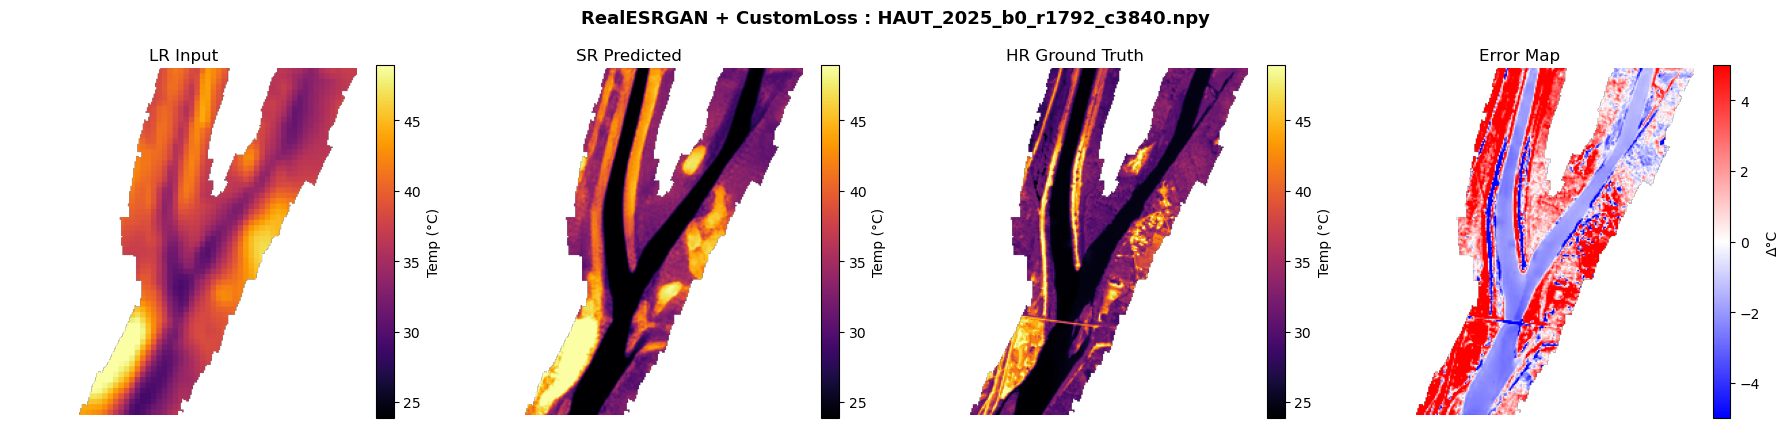

In [8]:
for sample in samples:
    fname = sample["fname"]
    MODEL_LABEL = f"RealESRGAN + CustomLoss : {fname}"
    # Cleanly unpack all prepared arrays and scale thresholds
    lr_256, hr_np, valid, vmin, vmax = prep_sample(sample)
    
    # 1. Run the model forward pass
    raw_sr = run_inference(model, sample)
    
    # 2. THE FIX: Explicitly mask out the background pixels on the SR prediction
    # This prevents unconstrained background noise from spilling into your plots
    sr_np = np.where(valid, raw_sr, np.nan)
    
    # 3. Compute residual map strictly over mutually valid space
    residual = sr_np - hr_np

    # Isolate valid residuals for a tightly scaled, symmetrical error map
    valid_res = residual[np.isfinite(residual)]
    res_lim = np.percentile(np.abs(valid_res), 98) if len(valid_res) > 0 else 3.0

    # Setup 4-panel visual inspector grid
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(f"{MODEL_LABEL}", fontsize=13, fontweight="bold")

    # Panel 0: Low-Res Input
    im_lr = axes[0].imshow(lr_256, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR Input"); axes[0].axis("off")
    plt.colorbar(im_lr, ax=axes[0], fraction=0.046, label="Temp (°C)")
    
    # Panel 1: Model Prediction
    im_sr = axes[1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR Predicted"); axes[1].axis("off")
    plt.colorbar(im_sr, ax=axes[1], fraction=0.046, label="Temp (°C)")
    
    # Panel 2: Ground Truth Target
    im_hr = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR Ground Truth"); axes[2].axis("off")
    plt.colorbar(im_hr, ax=axes[2], fraction=0.046, label="Temp (°C)")
    
    # Panel 3: Spatial Residual Errors
    im_res = axes[3].imshow(residual, cmap="bwr", vmin=-5, vmax=5)
    axes[3].set_title("Error Map"); axes[3].axis("off")
    plt.colorbar(im_res, ax=axes[3], fraction=0.046, label="Δ°C")

    plt.tight_layout()
    plt.show()

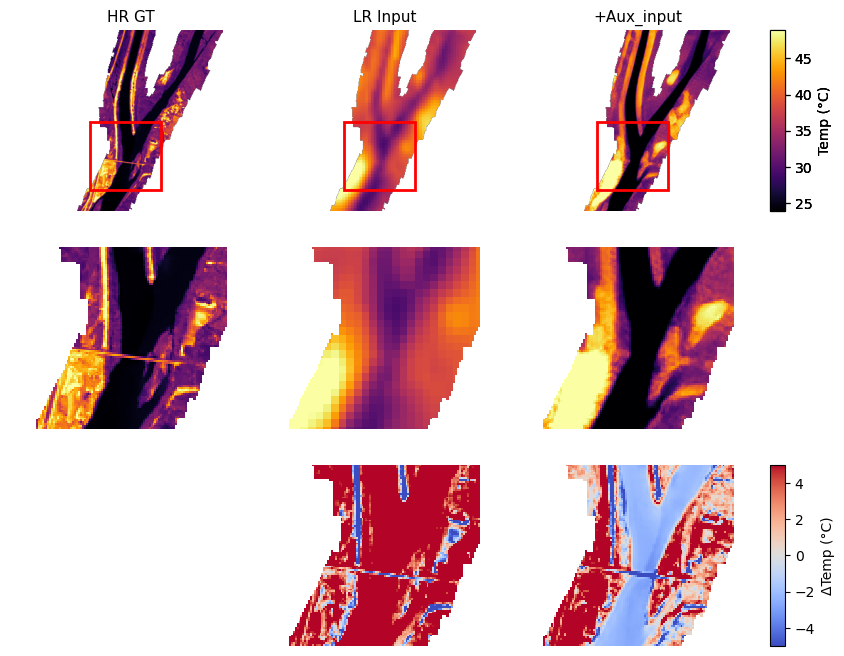

In [24]:
import os
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom  # or use cv2.resize / torchvision

# --- DEFINE YOUR BOX IN PIXELS ---
x, y, w, h = 70, 130, 100, 95  # top-left corner + size
row_slice = slice(y, y + h)  # derive slices once, reuse everywhere
col_slice = slice(x, x + w)

COL_LABELS = ["HR GT", "LR Input", "+Aux_input"] 

def add_zoom_box(ax, x, y, w, h, color="red", lw=2):
    ax.add_patch(
        mpatches.Rectangle(
            (x, y), w, h, linewidth=lw, edgecolor=color, facecolor="none"
        )
    )

for sample in samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # --- 1. UPSAMPLE LR TO HR RESOLUTION (if not already 256x256) ---
    if lr_np.shape != hr_np.shape:
        zoom_factors = (
            hr_np.shape[0] / lr_np.shape[0],
            hr_np.shape[1] / lr_np.shape[1],
        )
        lr_bicubic = zoom(lr_np, zoom_factors, order=3)  # order=3 is bicubic
    else:
        lr_bicubic = lr_np.copy()

    # Mask bicubic LR image
    lr_bicubic_masked = np.where(hr_mask > 0.5, lr_bicubic, np.nan)

    # --- 2. CALCULATE MODEL MAPS & RESIDUALS ---
    sr_maps, residuals = {}, {}

    # Calculate Bicubic Residual first
    residuals_ = np.where(hr_mask > 0.5, lr_bicubic_masked - hr_np, np.nan)

    sr_np = run_inference(model, sample)
    sr_np = np.where(hr_mask > 0.5, sr_np, np.nan)
    # sr_maps[model] = sr_np
    residuals = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)

    full_panels = [hr_np, lr_bicubic_masked, sr_np] 

    # --- 3. PLOTTING ---
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(
        3,
        4,
        width_ratios=[1, 1, 1, 0.06],
        hspace=0.2,
        wspace=0.06,
        figure=fig,
    )


    # Row 0: Full Patches
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[0, c])
        temp_im = ax.imshow(arr, cmap="inferno", vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=11)
        ax.axis("off")
        add_zoom_box(ax, x, y, w, h)
        fig.colorbar(temp_im, cax=fig.add_subplot(gs[0, 3]), label="Temp (°C)")

    # Row 1: Zoomed Crops
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[1, c])
        ax.imshow(
            arr[row_slice, col_slice],
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.axis("off")

    # Row 2: Error Maps
    # Column 0: Blank under HR (HR - HR = 0)
    fig.add_subplot(gs[2, 0]).axis("off")

    # Column 1: LR / Bicubic Residual
    ax_lr_err = fig.add_subplot(gs[2, 1])
    err_im = ax_lr_err.imshow(
        residuals_[row_slice, col_slice],
        cmap="coolwarm",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax_lr_err.axis("off")

    # Columns 2+: Model Residuals
    ax = fig.add_subplot(gs[2, 2 + 0])
    err_im = ax.imshow(
        residuals[row_slice, col_slice],
        cmap="coolwarm",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax.axis("off")
    fig.colorbar(err_im, cax=fig.add_subplot(gs[2, 3]), label="ΔTemp (°C)")

    # --- 4. SAVE FIGURE ---
    plt.savefig(
        "custom_loss.png", transparent=True, dpi=600, bbox_inches="tight", pad_inches=0
    )
    plt.show()
    plt.close(fig)  # Prevents notebook memory leaks across loops

### SPADE

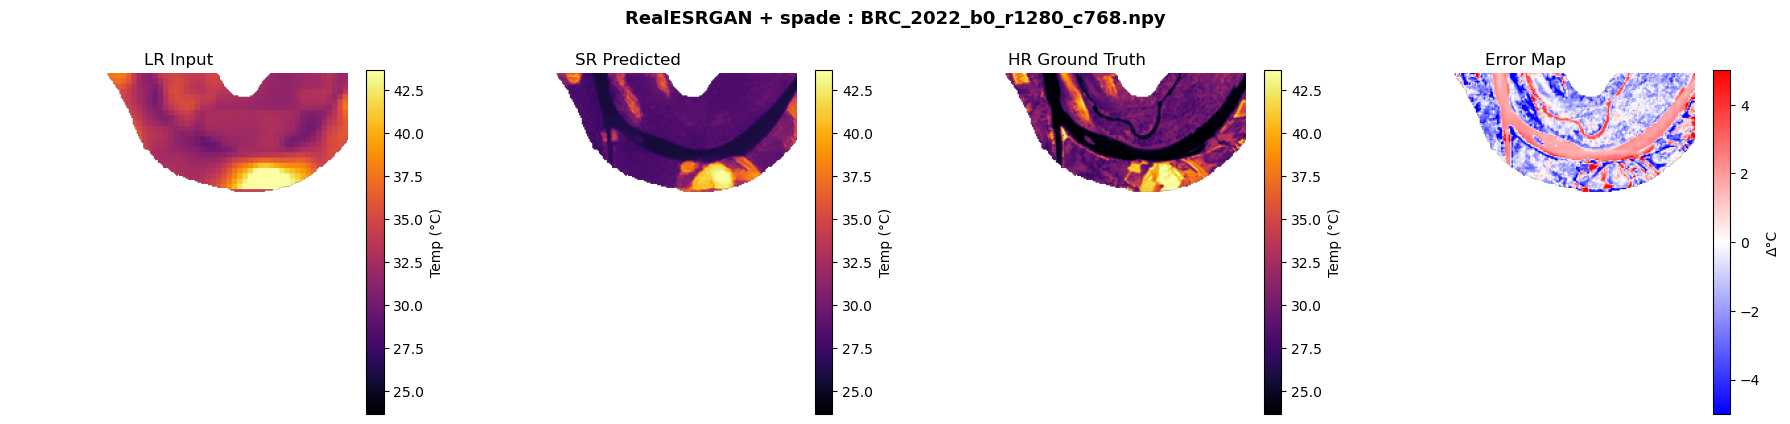

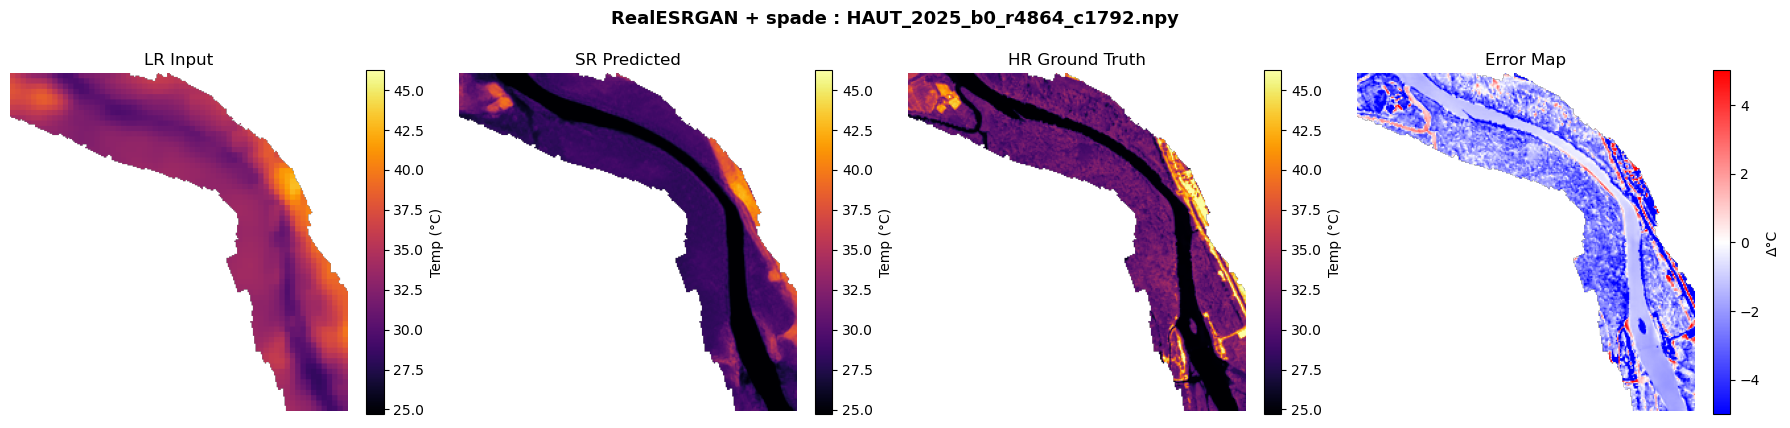

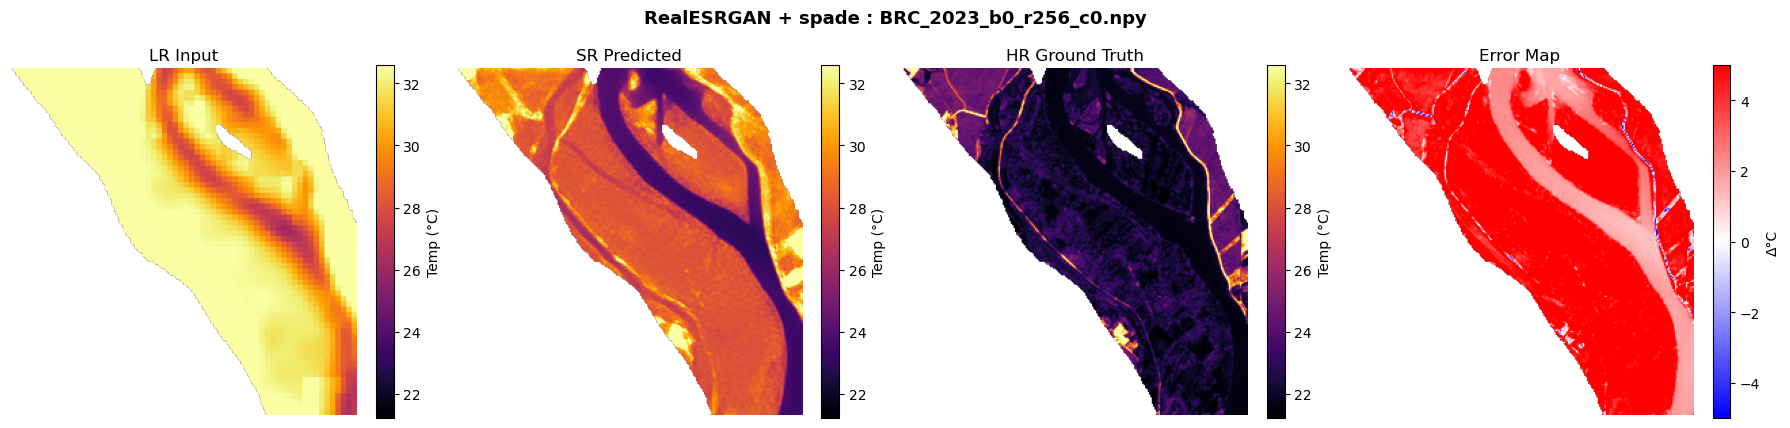

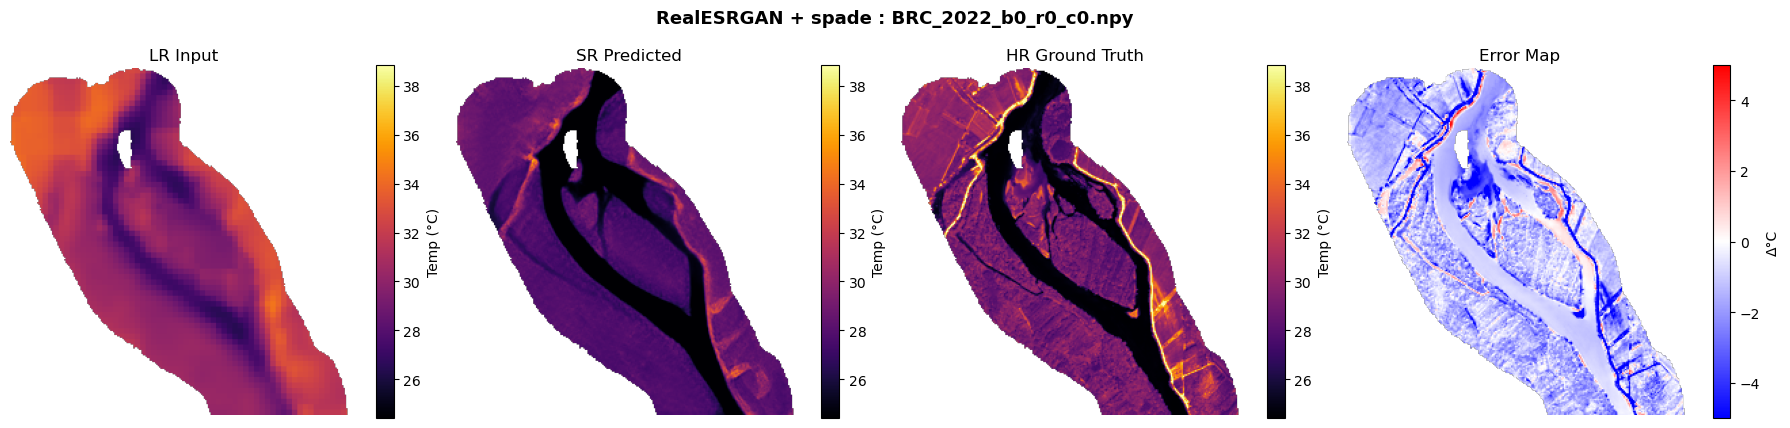

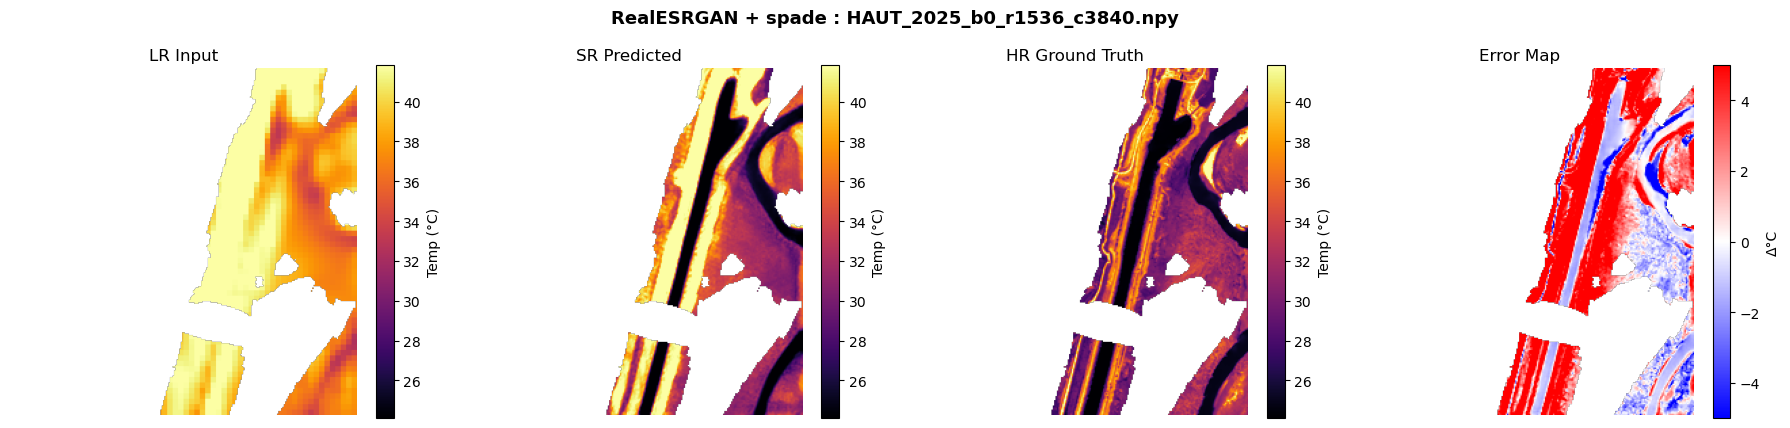

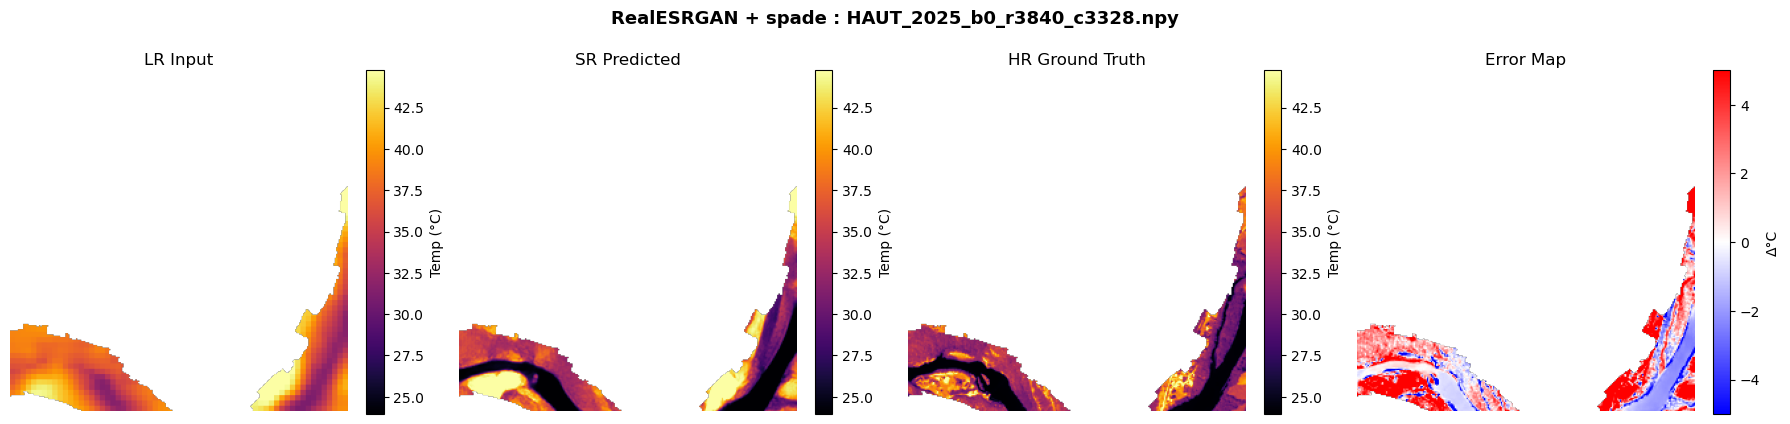

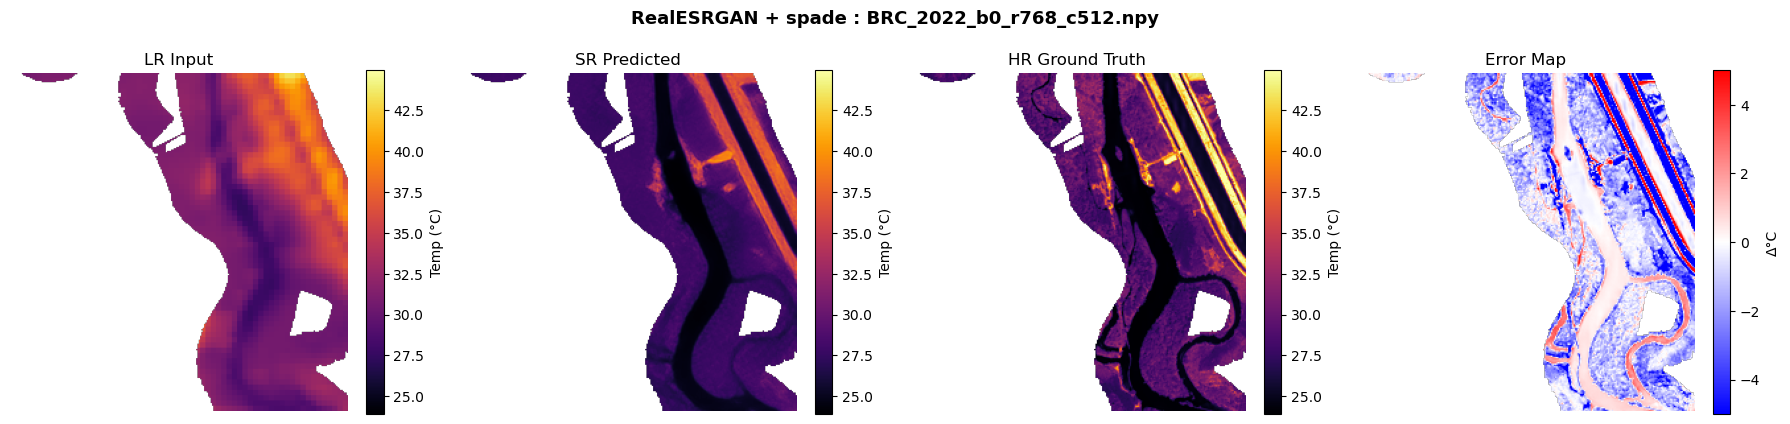

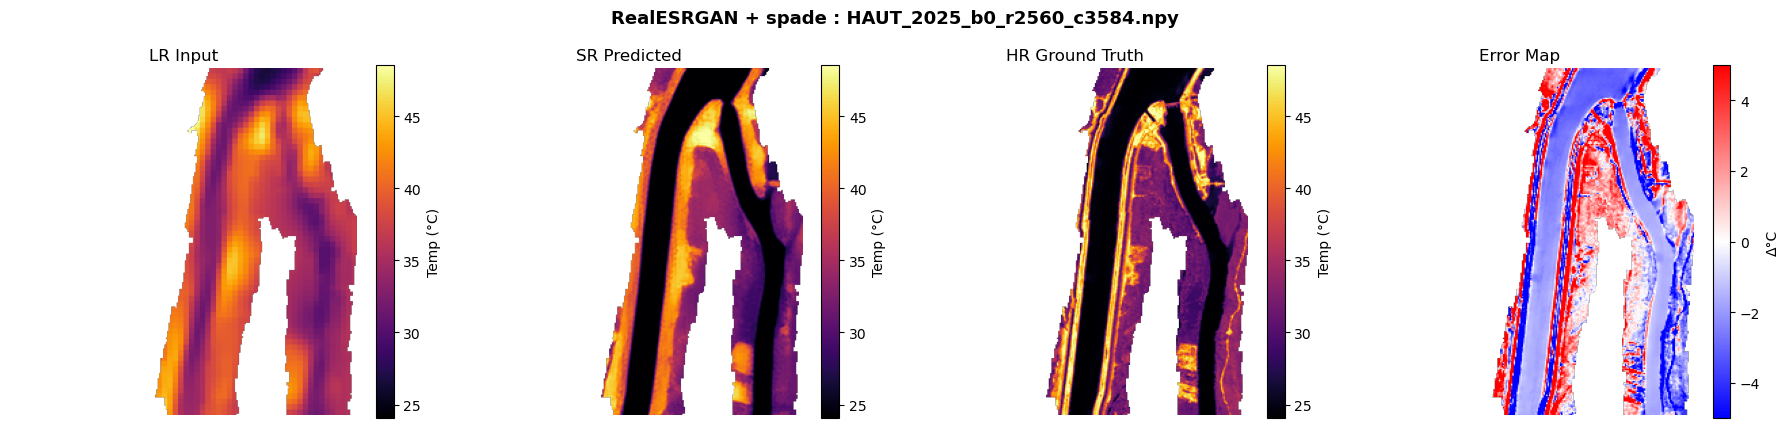

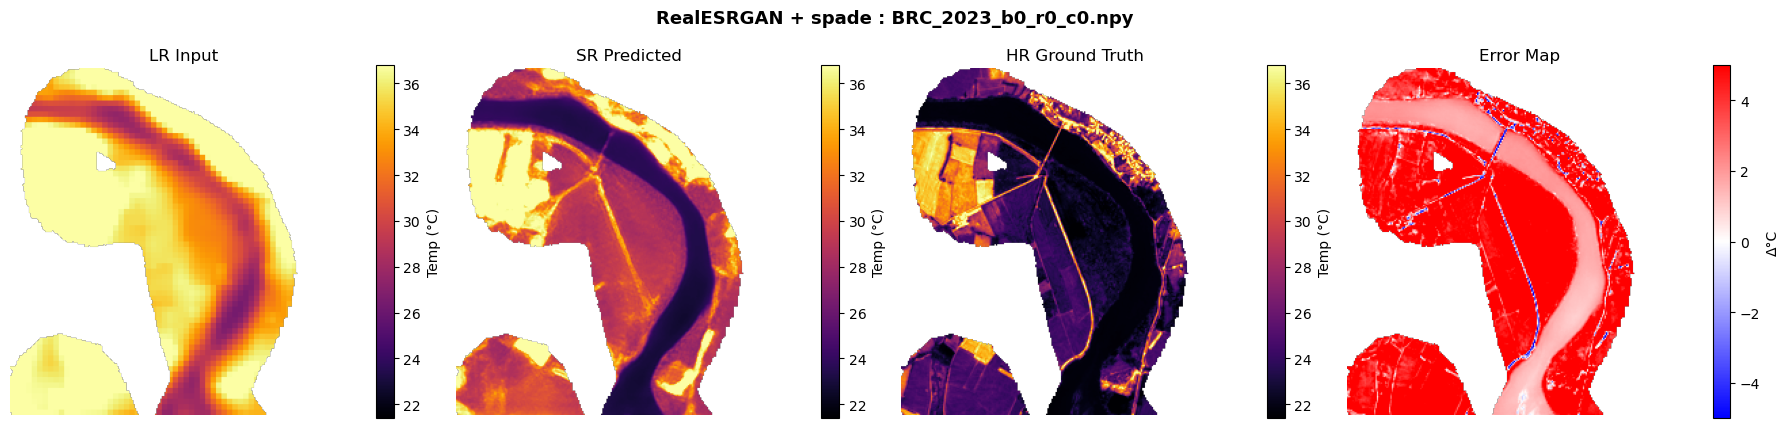

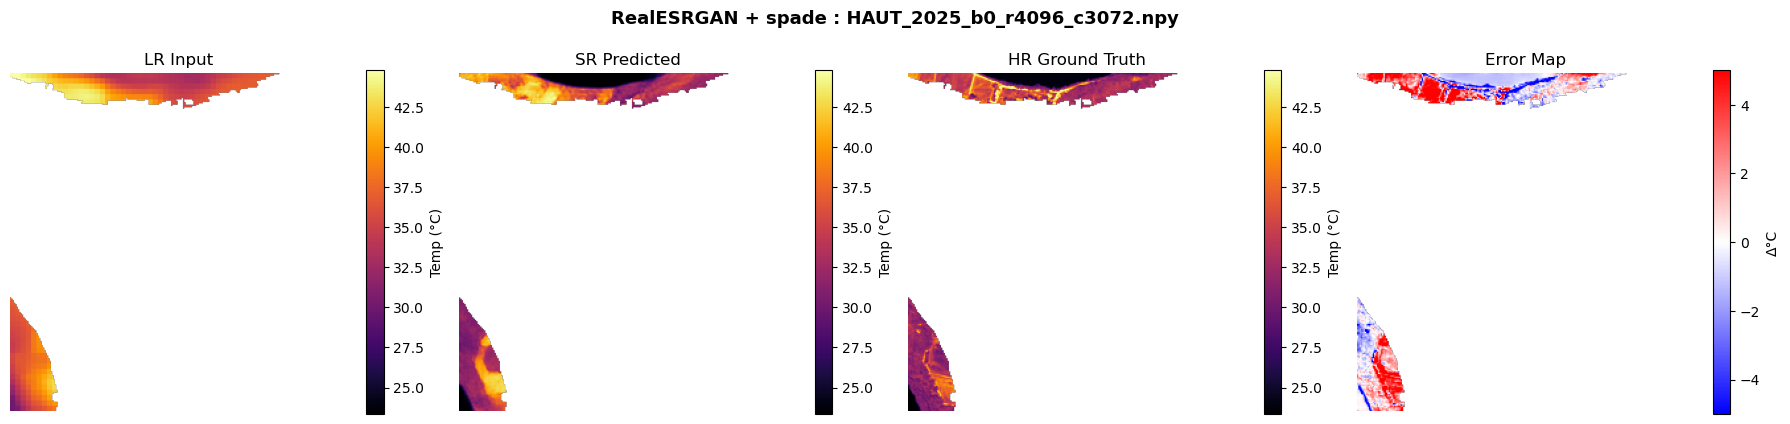

In [5]:
# with spade 
for sample in vis_samplest:
    fname = sample["fname"]
    MODEL_LABEL = f"RealESRGAN + spade : {fname}"
    # Cleanly unpack all prepared arrays and scale thresholds
    lr_256, hr_np, valid, vmin, vmax = prep_sample(sample)
    
    # 1. Run the model forward pass
    raw_sr = run_inference(model, sample)
    
    # 2. THE FIX: Explicitly mask out the background pixels on the SR prediction
    # This prevents unconstrained background noise from spilling into your plots
    sr_np = np.where(valid, raw_sr, np.nan)
    
    # 3. Compute residual map strictly over mutually valid space
    residual = sr_np - hr_np

    # Isolate valid residuals for a tightly scaled, symmetrical error map
    valid_res = residual[np.isfinite(residual)]
    res_lim = np.percentile(np.abs(valid_res), 98) if len(valid_res) > 0 else 3.0

    # Setup 4-panel visual inspector grid
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(f"{MODEL_LABEL}", fontsize=13, fontweight="bold")

    # Panel 0: Low-Res Input
    im_lr = axes[0].imshow(lr_256, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR Input"); axes[0].axis("off")
    plt.colorbar(im_lr, ax=axes[0], fraction=0.046, label="Temp (°C)")
    
    # Panel 1: Model Prediction
    im_sr = axes[1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR Predicted"); axes[1].axis("off")
    plt.colorbar(im_sr, ax=axes[1], fraction=0.046, label="Temp (°C)")
    
    # Panel 2: Ground Truth Target
    im_hr = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR Ground Truth"); axes[2].axis("off")
    plt.colorbar(im_hr, ax=axes[2], fraction=0.046, label="Temp (°C)")
    
    # Panel 3: Spatial Residual Errors
    im_res = axes[3].imshow(residual, cmap="bwr", vmin=-5, vmax=5)
    axes[3].set_title("Error Map"); axes[3].axis("off")
    plt.colorbar(im_res, ax=axes[3], fraction=0.046, label="Δ°C")

    plt.tight_layout()
    plt.show()

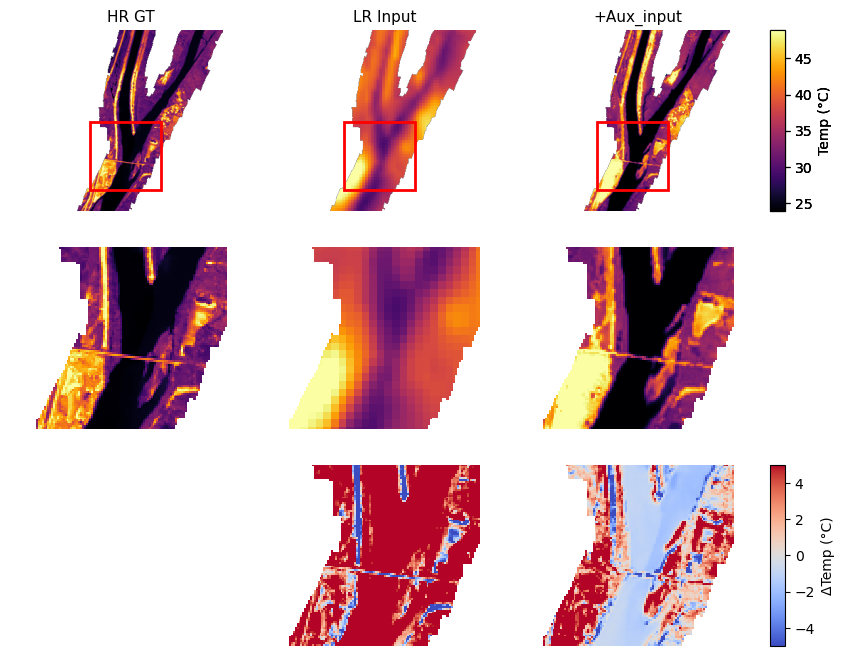

In [22]:
import os
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom  # or use cv2.resize / torchvision

# --- DEFINE YOUR BOX IN PIXELS ---
x, y, w, h = 70, 130, 100, 95  # top-left corner + size
row_slice = slice(y, y + h)  # derive slices once, reuse everywhere
col_slice = slice(x, x + w)

COL_LABELS = ["HR GT", "LR Input", "+Aux_input"] 

def add_zoom_box(ax, x, y, w, h, color="red", lw=2):
    ax.add_patch(
        mpatches.Rectangle(
            (x, y), w, h, linewidth=lw, edgecolor=color, facecolor="none"
        )
    )

for sample in samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # --- 1. UPSAMPLE LR TO HR RESOLUTION (if not already 256x256) ---
    if lr_np.shape != hr_np.shape:
        zoom_factors = (
            hr_np.shape[0] / lr_np.shape[0],
            hr_np.shape[1] / lr_np.shape[1],
        )
        lr_bicubic = zoom(lr_np, zoom_factors, order=3)  # order=3 is bicubic
    else:
        lr_bicubic = lr_np.copy()

    # Mask bicubic LR image
    lr_bicubic_masked = np.where(hr_mask > 0.5, lr_bicubic, np.nan)

    # --- 2. CALCULATE MODEL MAPS & RESIDUALS ---
    sr_maps, residuals = {}, {}

    # Calculate Bicubic Residual first
    residuals_ = np.where(hr_mask > 0.5, lr_bicubic_masked - hr_np, np.nan)

    sr_np = run_inference(model, sample)
    sr_np = np.where(hr_mask > 0.5, sr_np, np.nan)
    # sr_maps[model] = sr_np
    residuals = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)

    full_panels = [hr_np, lr_bicubic_masked, sr_np] 

    # --- 3. PLOTTING ---
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(
        3,
        4,
        width_ratios=[1, 1, 1, 0.06],
        hspace=0.2,
        wspace=0.06,
        figure=fig,
    )


    # Row 0: Full Patches
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[0, c])
        temp_im = ax.imshow(arr, cmap="inferno", vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=11)
        ax.axis("off")
        add_zoom_box(ax, x, y, w, h)
        fig.colorbar(temp_im, cax=fig.add_subplot(gs[0, 3]), label="Temp (°C)")

    # Row 1: Zoomed Crops
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[1, c])
        ax.imshow(
            arr[row_slice, col_slice],
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.axis("off")

    # Row 2: Error Maps
    # Column 0: Blank under HR (HR - HR = 0)
    fig.add_subplot(gs[2, 0]).axis("off")

    # Column 1: LR / Bicubic Residual
    ax_lr_err = fig.add_subplot(gs[2, 1])
    err_im = ax_lr_err.imshow(
        residuals_[row_slice, col_slice],
        cmap="coolwarm",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax_lr_err.axis("off")

    # Columns 2+: Model Residuals
    ax = fig.add_subplot(gs[2, 2 + 0])
    err_im = ax.imshow(
        residuals[row_slice, col_slice],
        cmap="coolwarm",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax.axis("off")
    fig.colorbar(err_im, cax=fig.add_subplot(gs[2, 3]), label="ΔTemp (°C)")

    # --- 4. SAVE FIGURE ---
    plt.savefig(
        "spade.png", transparent=True, dpi=600, bbox_inches="tight", pad_inches=0
    )
    plt.show()
    plt.close(fig)  # Prevents notebook memory leaks across loops

### CDF

In [3]:
import numpy as np
import pandas as pd

def extract_water_pixels(dataset, model_obj, model_name="Baseline", save_path=None):
    all_hr, all_lr, all_sr, all_residuals, all_sample_ids = [], [], [], [], []

    for idx, sample in enumerate(dataset):
        hr_mask = sample["hr_mask"].squeeze(0)
        water_mask = sample["water_mask"].squeeze(0)

        pure_water = (hr_mask > 0.5) & (water_mask > 0.5)
        if pure_water.sum() < 10:
            continue

        sr_np = run_inference(model_obj, sample)

        # Denormalize TIR channels
        hr_np = (sample["hr"][0].numpy() * HR_STD) + HR_MEAN
        lr_np = (sample["lr"][0].numpy() * LR_STD) + LR_MEAN

        # Upscale LR TIR to match HR/SR grid
        lr_up = np.repeat(np.repeat(lr_np, 4, axis=0), 4, axis=1)

        pure_water = pure_water.numpy()
        valid = (pure_water & np.isfinite(hr_np) & np.isfinite(sr_np) & np.isfinite(lr_up))
        if valid.sum() == 0:
            continue

        hr_water = hr_np[valid]
        lr_water = lr_up[valid]
        sr_water = sr_np[valid]
        residual = sr_water - hr_water

        all_hr.append(hr_water)
        all_lr.append(lr_water)
        all_sr.append(sr_water)
        all_residuals.append(residual)
        all_sample_ids.extend([idx] * len(residual))

    # Flatten into 1D NumPy arrays
    sample_ids_v = np.array(all_sample_ids)
    hr_v = np.concatenate(all_hr)
    lr_v = np.concatenate(all_lr)
    sr_v = np.concatenate(all_sr)
    residual_v = np.concatenate(all_residuals)

    # File path handling
    if save_path is None:
        save_path = f"water_pixels_{model_name.lower().replace(' ', '_')}.npz"

    # Save to compressed NPZ
    np.savez_compressed(
        save_path,
        sample_id=sample_ids_v,
        hr_temp=hr_v,
        lr_temp=lr_v,
        sr_temp=sr_v,
        residual=residual_v,
        model_name=model_name
    )
    
    print(f"Saved {len(residual_v):,} water pixels to {save_path}")

    # Return a DataFrame for immediate plotting if needed
    return pd.DataFrame({
        "sample_id": sample_ids_v,
        "hr_temp": hr_v,
        "lr_temp": lr_v,
        "sr_temp": sr_v,
        "residual": residual_v,
        "model": model_name
    })

In [ ]:
spade_df = extract_water_pixels(
    dataset=test_ds,
    model_obj=model,
    model_name="spade",
    save_path="spade_wt_px.npz"
)

Saved 440,308 water pixels to spade_wt_px.npz


In [4]:
# Run and save individually
def load_npz_to_df(npz_path):
    data = np.load(npz_path)
    return pd.DataFrame({
        "sample_id": data["sample_id"],
        "hr_temp": data["hr_temp"],
        "lr_temp": data["lr_temp"],
        "sr_temp": data["sr_temp"],
        "residual": data["residual"],
        "model": str(data["model_name"])
    })

# Usage
base_df    = load_npz_to_df(BASE / "results/stats/base_wt_px.npz")
aux_df    = load_npz_to_df(BASE / "results/stats/aux_wt_px.npz")
spade_df    = load_npz_to_df(BASE / "results/stats/spade_wt_px.npz")


# Combine for Seaborn plotting
df_all = pd.concat([base_df, aux_df, spade_df], ignore_index=True)

In [13]:
# Access array shapes directly from DataFrame columns
print("HR shape:", spade_df["hr_temp"].shape)
print("LR shape:", spade_df["lr_temp"].shape)
print("SR shape:", spade_df["sr_temp"].shape)

print("\nResidual dataframe:")
print(spade_df.head())

print("\nResidual statistics:")
print(spade_df["residual"].describe())

HR shape: (440308,)
LR shape: (440308,)
SR shape: (440308,)

Residual dataframe:
   sample_id    hr_temp    lr_temp    sr_temp  residual  model
0          0  26.249920  30.348972  26.778187  0.528267  spade
1          0  24.353935  30.348972  25.130779  0.776844  spade
2          0  24.580086  30.348972  24.432467 -0.147619  spade
3          0  24.538200  28.688614  24.357244 -0.180956  spade
4          0  24.470631  28.688614  24.292810 -0.177820  spade

Residual statistics:
count    440308.000000
mean          0.145236
std           2.629446
min         -47.700226
25%          -1.151294
50%          -0.201632
75%           1.412056
max          25.467491
Name: residual, dtype: float64


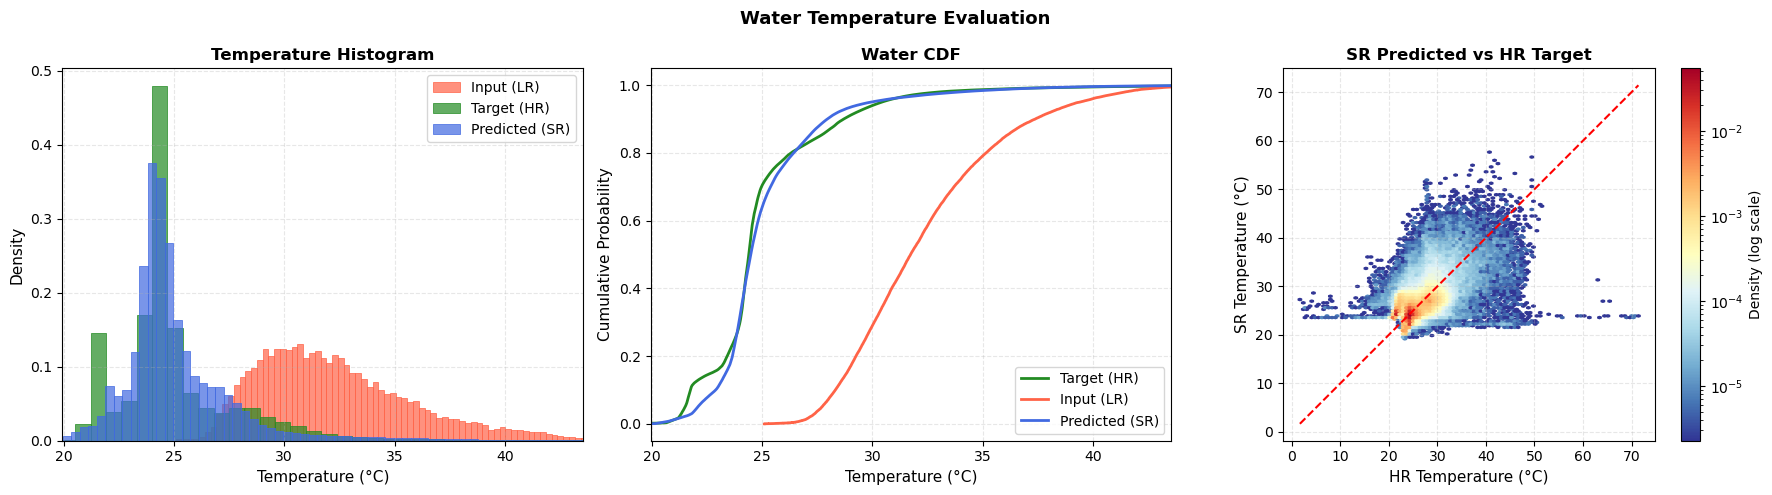

In [ ]:
# --- Common Limits for Histogram and CDF ---
padding = 1.0  
xmin = np.percentile(spade_df["hr_temp"].values, 1) - padding
xmax = np.percentile(spade_df["lr_temp"].values, 99) + padding

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Water Temperature Evaluation", fontsize=13, fontweight="bold")

# Palette setup
palette = {"HR": "forestgreen", "SR": "royalblue", "LR": "tomato"}

# ---------------- Panel 1: Histogram + KDE ----------------
ax_hist = axes[0]
# Plotting order: Input (LR) background, Target (HR) and Predicted (SR) foreground
for vec, key, lbl in [(spade_df["lr_temp"].values, "LR", "Input (LR)"), 
                      (spade_df["hr_temp"].values, "HR", "Target (HR)"), 
                      (spade_df["sr_temp"].values, "SR", "Predicted (SR)")]:
    
    sns.histplot(
        vec,
        ax=ax_hist,
        bins=100,
        stat="density",              
        kde=False,                 
        color=palette[key],
        label=lbl,
        alpha=0.7,                # Soft bar shading
        edgecolor=palette[key],        
        linewidth=0.5,
        line_kws={"linewidth": 1.0}  # Smooth KDE curve thickness
    )

ax_hist.set_title("Temperature Histogram", fontsize=12, fontweight="bold")
ax_hist.set_xlabel("Temperature (°C)", fontsize=11)
ax_hist.set_ylabel("Density", fontsize=11)            # Raw pixel count
ax_hist.set_xlim(xmin, xmax)
ax_hist.grid(True, linestyle="--", alpha=0.3)
ax_hist.legend(loc="upper right", frameon=True)

# ---------------- Panel 2: Water CDF ----------------
ax_cdf = axes[1]
for vec, key, lbl in [(spade_df["hr_temp"].values, "HR", "Target (HR)"), 
                      (spade_df["lr_temp"].values, "LR", "Input (LR)"),
                      (spade_df["sr_temp"].values, "SR", "Predicted (SR)")]:
    
    sorted_data = np.sort(vec)
    y_values = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax_cdf.plot(sorted_data, y_values, color=palette[key], lw=2.0, label=lbl)

ax_cdf.set_title("Water CDF", fontsize=12, fontweight="bold")
ax_cdf.set_xlabel("Temperature (°C)", fontsize=11)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=11)
ax_cdf.set_xlim(xmin, xmax) 
# ax_cdf.grid(True, linestyle="--", alpha=0.3)
ax_cdf.legend(loc="lower right", frameon=True)

# ---------------- Panel 3: Hexbin (1:1 Scatter) ----------------
from matplotlib.colors import LogNorm

ax_scat = axes[2]
weights = np.ones_like(spade_df["hr_temp"].values) / len(spade_df["hr_temp"].values)
hb = ax_scat.hexbin(
    spade_df["hr_temp"].values, spade_df["sr_temp"].values,
    C=weights, reduce_C_function=np.sum,
    gridsize=100,
    cmap="RdYlBu_r",
    mincnt=1,
    norm=LogNorm(),   
)

temp_min, temp_max = min(spade_df["hr_temp"].values.min(), spade_df["sr_temp"].values.min()), max(spade_df["hr_temp"].values.max(), spade_df["sr_temp"].values.max())  # renamed, was global_min/max
ax_scat.plot([temp_min, temp_max], [temp_min, temp_max], "r--", lw=1.5)

ax_scat.set_title("SR Predicted vs HR Target", fontsize=12, fontweight="bold")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=11)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=11)
ax_scat.set_aspect("equal")
# ax_scat.grid(True, linestyle="--", alpha=0.3)
fig.colorbar(hb, ax=ax_scat, label="Density (log scale)")

plt.tight_layout()
plt.savefig(
        "stats_fig_spade.png", dpi=600, bbox_inches="tight", pad_inches=0
    )
plt.show()

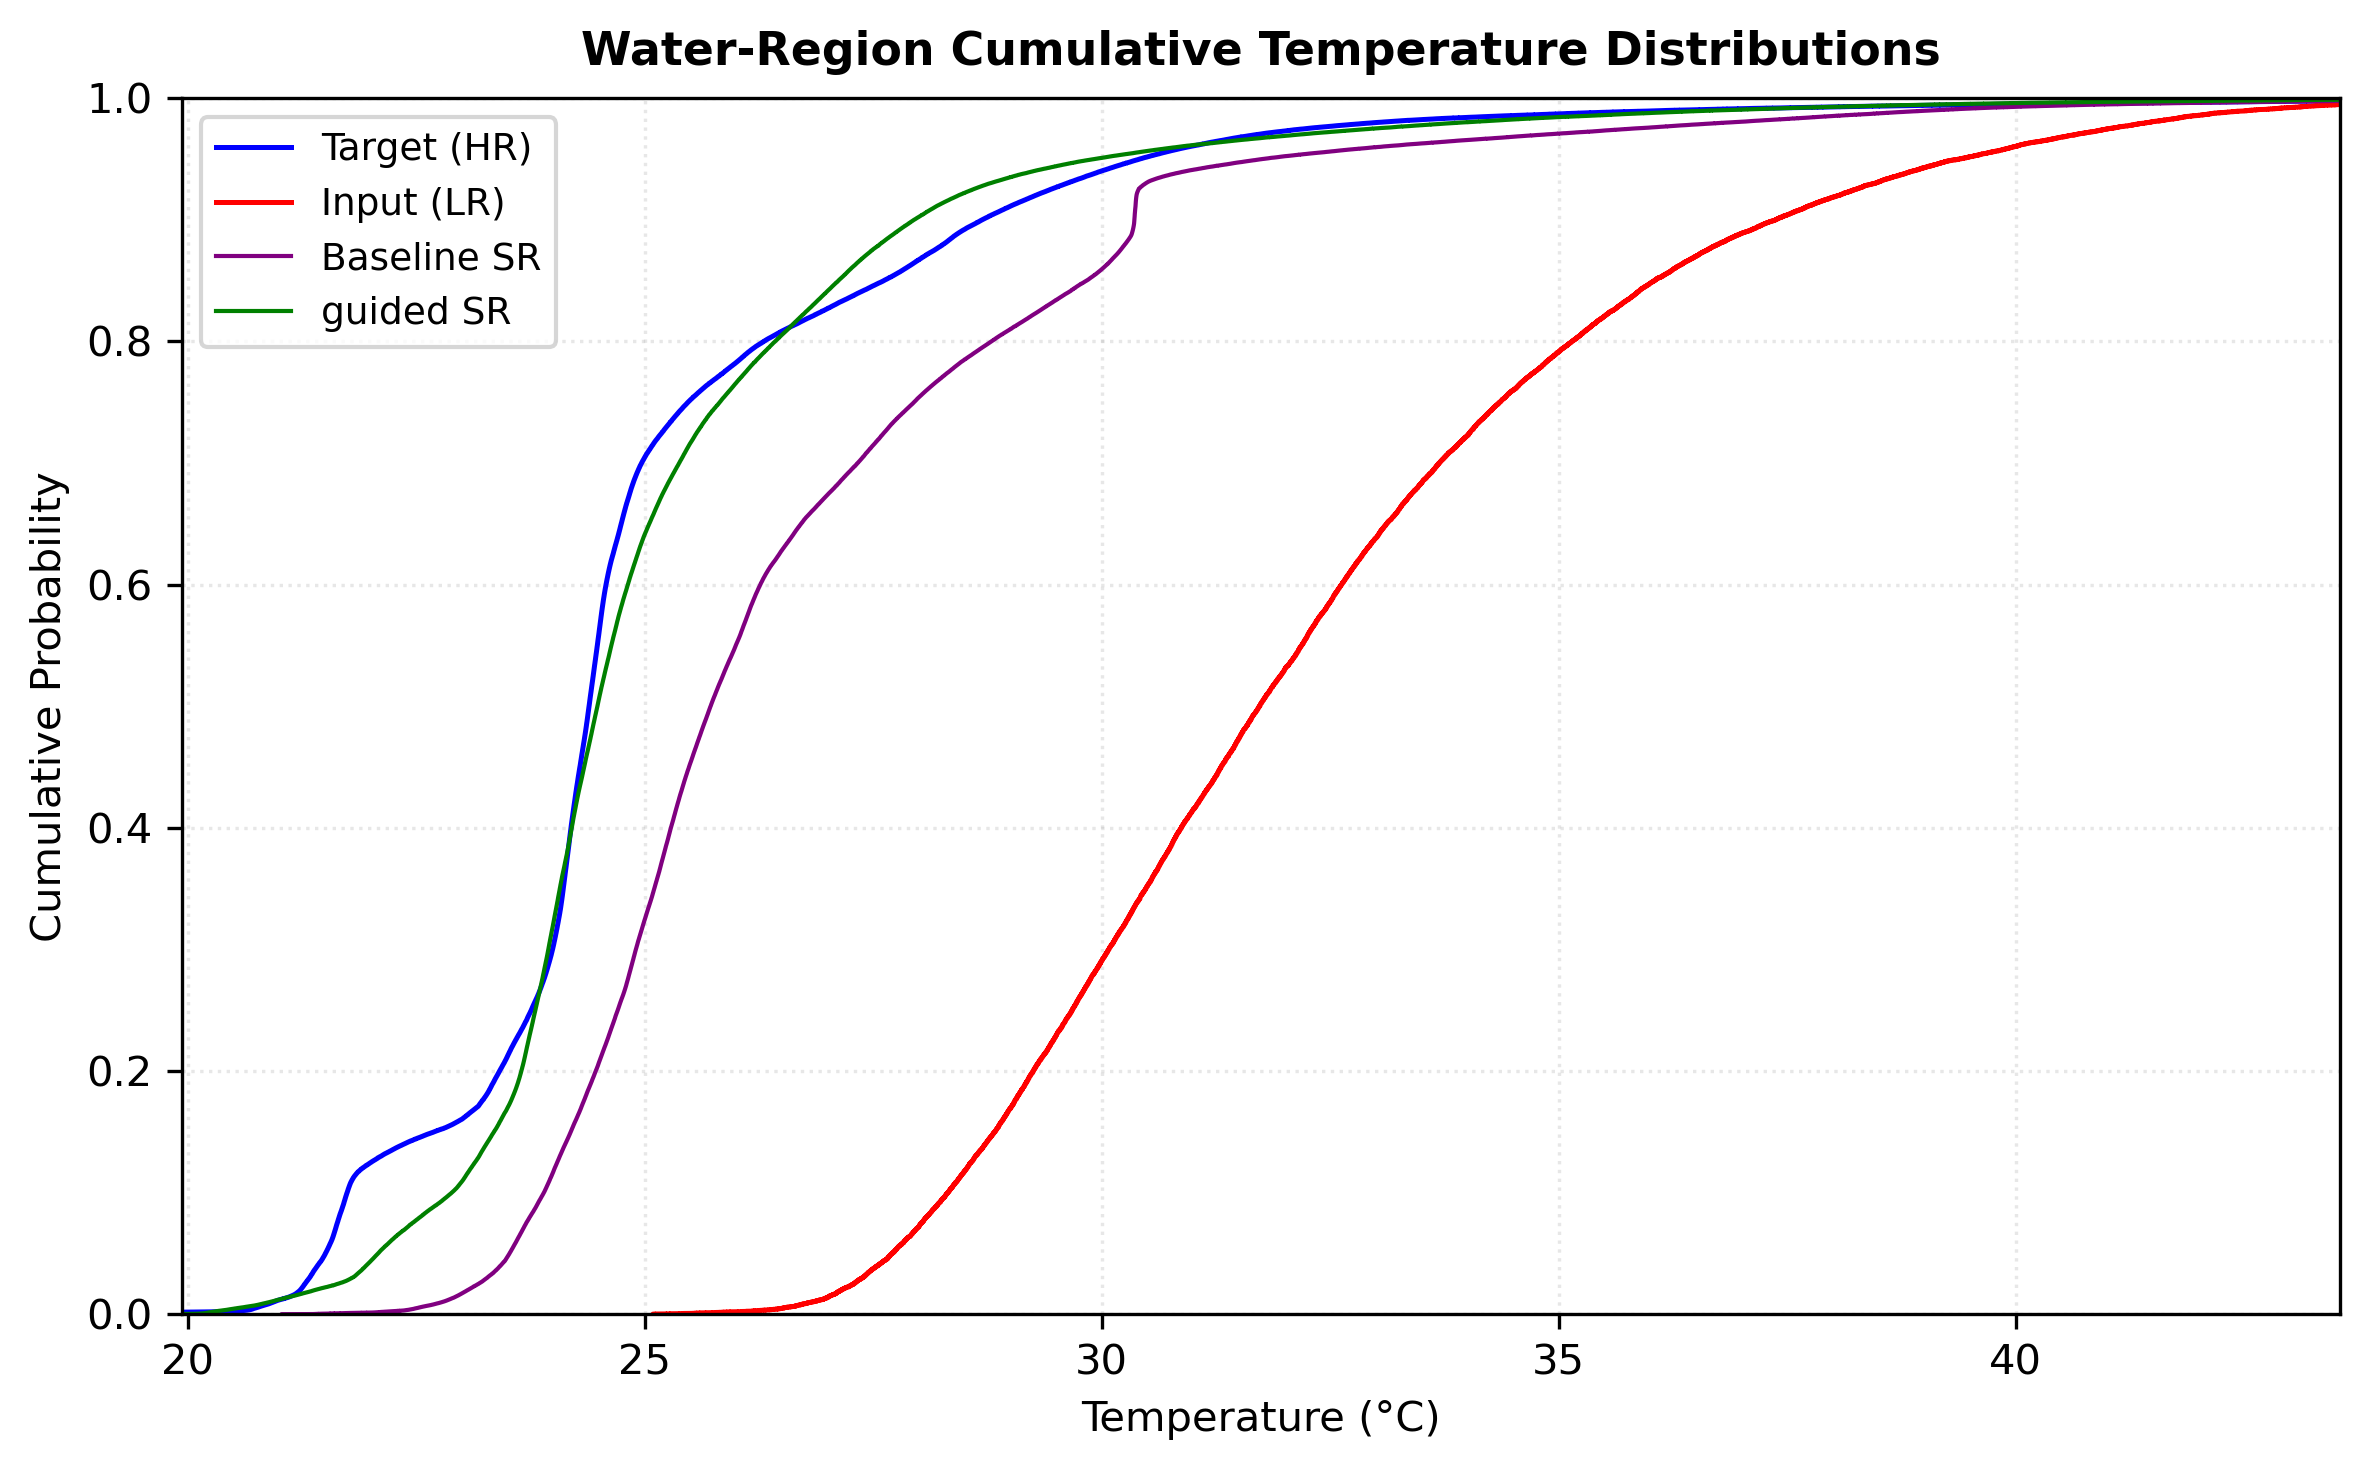

In [17]:
## combined CDF
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

padding = 1.0  
xmin = np.percentile(spade_df["hr_temp"].values, 1) - padding
xmax = np.percentile(spade_df["lr_temp"].values, 99) + padding

# Set thesis publication style
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 10})

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Reference distributions (using ground truth & input from baseline dataframe)
sns.ecdfplot(data=base_df, x="hr_temp", label="Target (HR)", color="blue",  linewidth=1.2, ax=ax)
sns.ecdfplot(data=base_df, x="lr_temp", label="Input (LR)", color="red", linewidth=1.2, ax=ax)

# Model outputs
sns.ecdfplot(data=base_df, x="sr_temp", label="Baseline SR", color="purple",linewidth=1, ax=ax)
# sns.ecdfplot(data=aux_df,      x="sr_temp", label="Auxiliary SR", color="orange", linewidth=1, ax=ax)
sns.ecdfplot(data=spade_df,    x="sr_temp", label="guided SR", color="green", linewidth=1, ax=ax)

# Formatting
ax.set_title("Water-Region Cumulative Temperature Distributions", fontsize=11, fontweight="bold", pad=8)
ax.set_xlabel("Temperature (°C)", fontsize=10)
ax.set_ylabel("Cumulative Probability", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.3)
ax.set_xlim(xmin, xmax) 
ax.legend(frameon=True, loc="upper left", fontsize=9)

# Crop bounds to eliminate far outliers
# plt.xlim([20, 45])  # Adjust lower/upper limits to match your water temperature range

plt.tight_layout()
plt.savefig("cdf_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

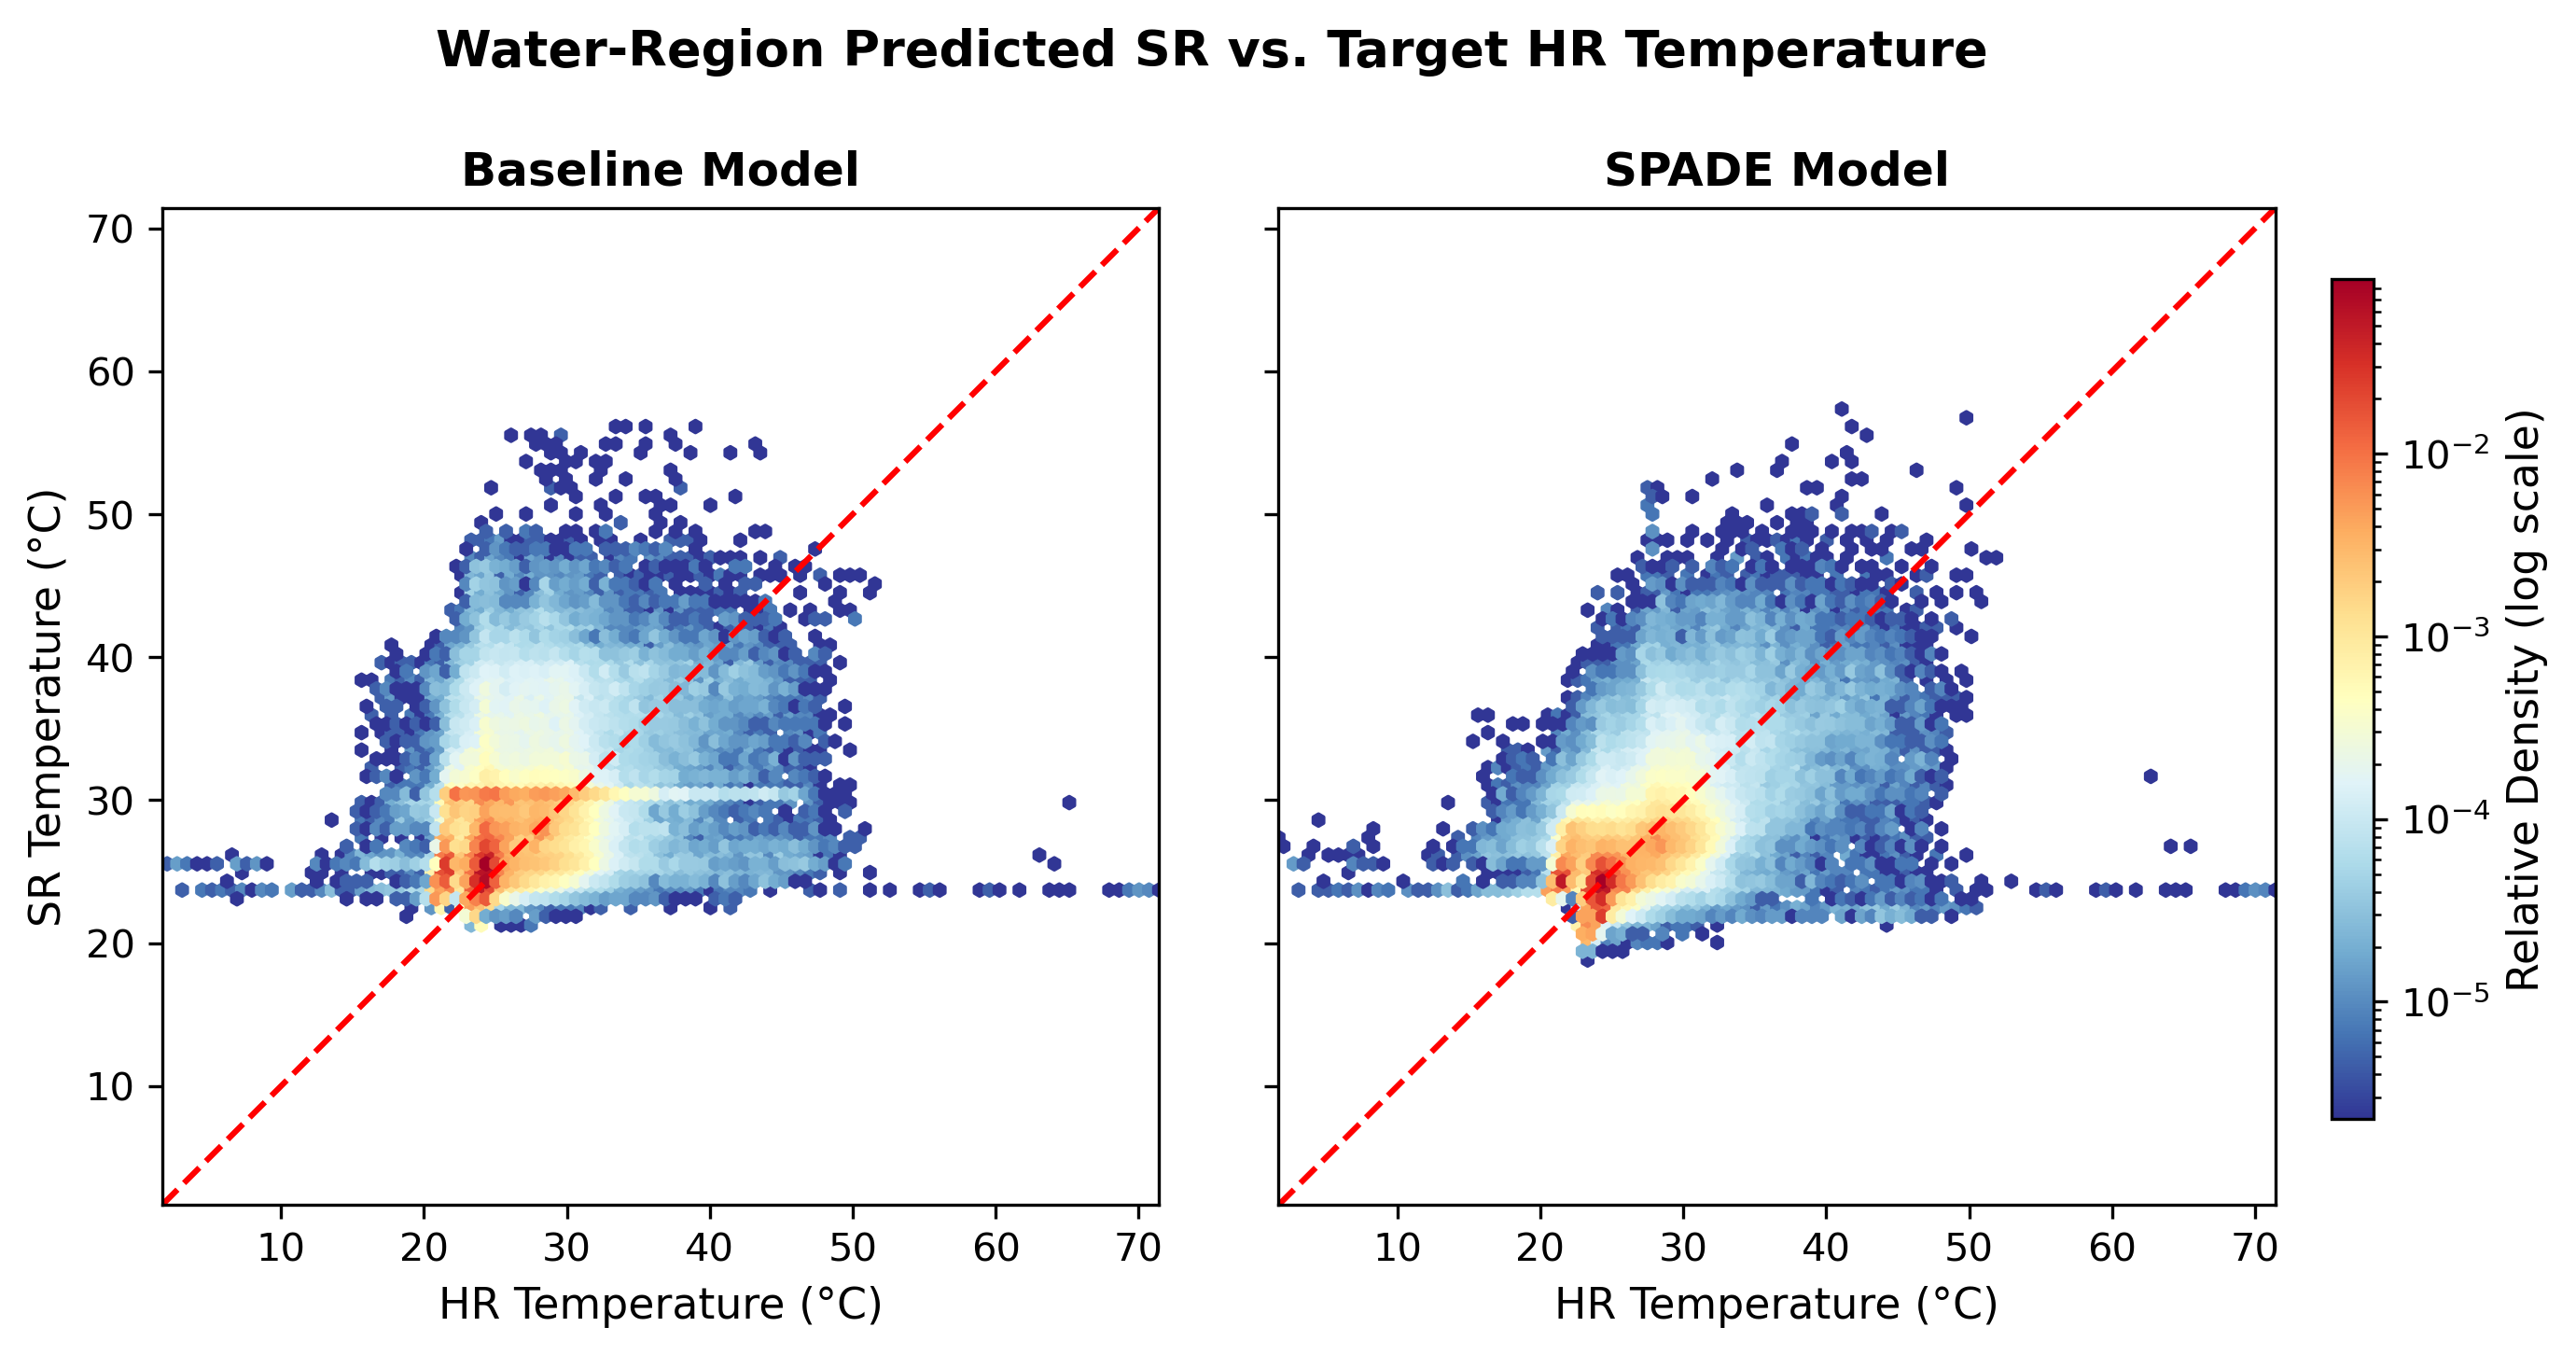

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# Set publication style
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 10})

# 1. Compute global bounds across ALL models for true 1:1 axis alignment
temp_min, temp_max = min(df_all["hr_temp"].values.min(), df_all["sr_temp"].values.min()), max(df_all["hr_temp"].values.max(), df_all["sr_temp"].values.max())  # renamed, was global_min/max

# 2. Setup 1x3 horizontal subplot grid
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True, dpi=300)

model_runs = [
    ("Baseline", base_df),
    # ("Auxiliary", aux_df),
    ("SPADE", spade_df)
]

hb_last = None
for ax, (title, df) in zip(axes, model_runs):
    hr_vals = df["hr_temp"].values
    sr_vals = df["sr_temp"].values
    
    # Normalized weights (relative density per model)
    weights = np.ones_like(hr_vals) / len(hr_vals)
    
    # Preferred Hexbin setup
    hb = ax.hexbin(
        hr_vals, sr_vals,
        C=weights, reduce_C_function=np.sum,
        gridsize=100,
        cmap="RdYlBu_r",
        mincnt=1,
        norm=LogNorm(),
        extent=[temp_min, temp_max, temp_min, temp_max]  # Forces identical coordinate extent across subplots
    )
    hb_last = hb

    # 1:1 Reference Line
    ax.plot([temp_min, temp_max], [temp_min, temp_max], "r--", lw=1.5)

    # # Statistical metric annotation box
    # r2 = np.corrcoef(hr_vals, sr_vals)[0, 1] ** 2
    # rmse = np.sqrt(np.mean((sr_vals - hr_vals) ** 2))
    # ax.text(
    #     0.05, 0.82,
    #     f"$R^2 = {r2:.3f}$\n$\text{{RMSE}} = {rmse:.2f}^\circ\text{{C}}$",
    #     transform=ax.transAxes,
    #     fontsize=9,
    #     bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85)
    # )

    # Subplot formatting
    ax.set_title(f"{title} Model", fontsize=12, fontweight="bold")
    ax.set_xlabel("HR Temperature (°C)", fontsize=11)
    ax.set_xlim([temp_min, temp_max])
    ax.set_ylim([temp_min, temp_max])
    ax.set_aspect("equal")

axes[0].set_ylabel("SR Temperature (°C)", fontsize=11)

# Single unified colorbar on the right
fig.subplots_adjust(right=0.88, wspace=0.12)
cbar_ax = fig.add_axes([0.90, 0.20, 0.015, 0.60])
cbar = fig.colorbar(hb_last, cax=cbar_ax)
cbar.set_label("Relative Density (log scale)", fontsize=11)

plt.suptitle("Water-Region Predicted SR vs. Target HR Temperature", fontsize=13, fontweight="bold", y=0.98)
plt.savefig("scatter_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

In [2]:
### Patch metrics
import pandas as pd
df = pd.read_csv("/share/home/e2406751/Superresolution-TIR/results/spade_test_patch_metrics.csv")
print(df.groupby("campaign")[["water_mae", "land_mae"]].describe())

          water_mae                                                    \
              count      mean       std       min       25%       50%   
campaign                                                                
BRC_2022       12.0  1.198586  0.271366  0.842988  0.998080  1.213609   
BRC_2023       12.0  3.338397  0.389307  2.537097  3.174619  3.294147   
HAUT_2025      48.0  1.492297  0.680414  0.501154  0.955190  1.263171   

                              land_mae                                \
                75%       max    count      mean       std       min   
campaign                                                               
BRC_2022   1.383005  1.786625     12.0  2.289288  1.215691  1.054784   
BRC_2023   3.550567  3.975082     12.0  5.276999  0.823910  3.990881   
HAUT_2025  1.960285  3.385539     48.0  3.501652  1.469226  1.608804   

                                                   
                25%       50%       75%       max  
campaign                

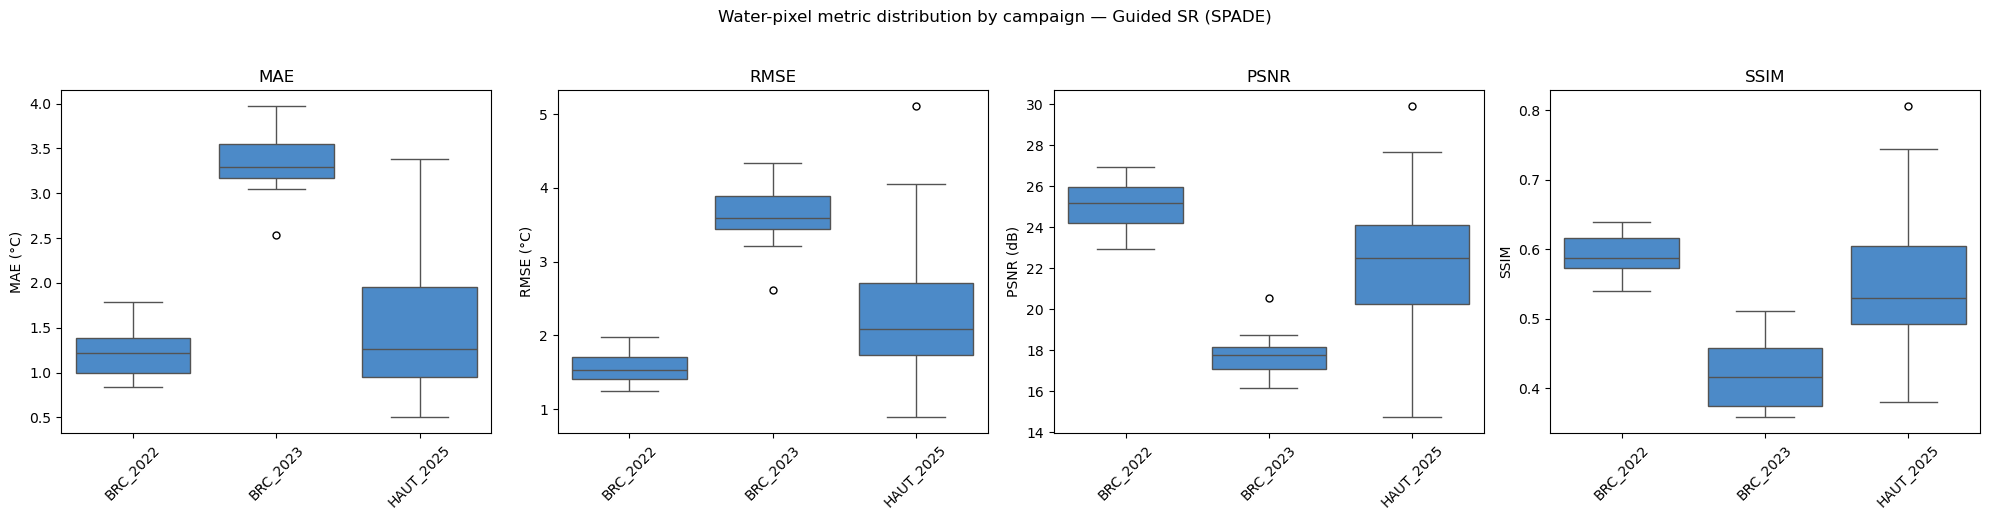

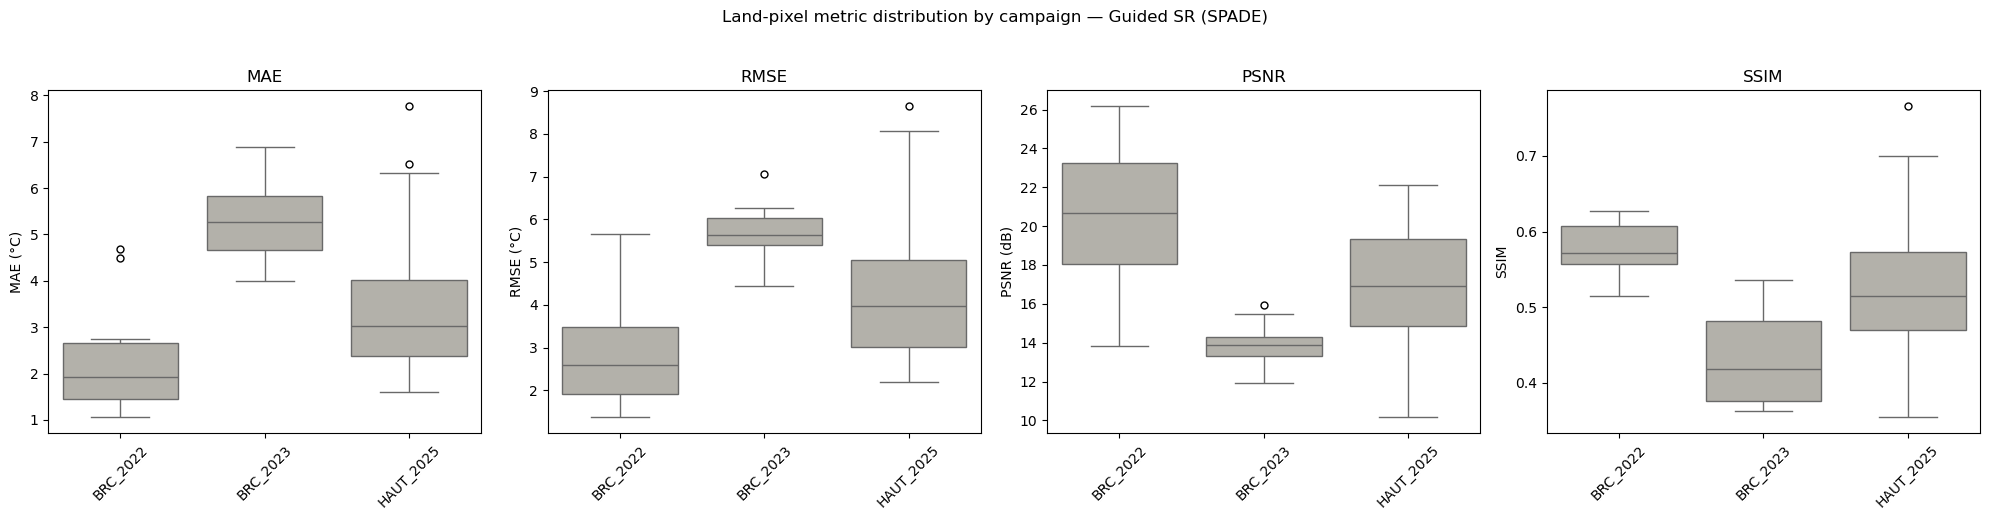

          water_mae                     water_rmse                      \
             median      mean       std     median      mean       std   
campaign                                                                 
BRC_2022   1.213609  1.198586  0.271366   1.530571  1.576362  0.238548   
BRC_2023   3.294147  3.338397  0.389307   3.594673  3.610752  0.450062   
HAUT_2025  1.263171  1.492297  0.680414   2.083874  2.257144  0.816770   

          water_psnr                      water_ssim  ...  land_mae land_rmse  \
              median       mean       std     median  ...       std    median   
campaign                                              ...                       
BRC_2022   25.201487  25.033199  1.286763   0.587999  ...  1.215691  2.585531   
BRC_2023   17.786032  17.811765  1.138440   0.415642  ...  0.823910  5.621197   
HAUT_2025  22.520988  22.339308  2.998054   0.530001  ...  1.469226  3.973457   

                               land_psnr                      land_s

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/share/home/e2406751/Superresolution-TIR/results/spade_test_patch_metrics.csv")

CAMPAIGN_ORDER = ["BRC_2022", "BRC_2023", "HAUT_2025"]  # adjust to your actual campaign set/order
df = df[df["campaign"].isin(CAMPAIGN_ORDER)]  # drop "unknown" rows if the regex missed any fnames

water_metrics = ["water_mae", "water_rmse", "water_psnr", "water_ssim"]
water_labels  = ["MAE (°C)", "RMSE (°C)", "PSNR (dB)", "SSIM"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric, label in zip(axes, water_metrics, water_labels):
    sns.boxplot(
        data=df, x="campaign", y=metric, ax=ax,
        order=CAMPAIGN_ORDER,
        flierprops=dict(marker="o", markerfacecolor="none",
                         markeredgecolor="black", markersize=5),
        color="#378ADD"
    )
    ax.set_ylabel(label)
    ax.set_xlabel("")
    ax.set_title(label.split(" ")[0])
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Water-pixel metric distribution by campaign — Guided SR (SPADE)", y=1.03)
plt.tight_layout()
# plt.savefig("spade_boxplot_water_by_campaign.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Land (non-water) — secondary figure ─────────────────────────────────
land_metrics = ["land_mae", "land_rmse", "land_psnr", "land_ssim"]
land_labels  = ["MAE (°C)", "RMSE (°C)", "PSNR (dB)", "SSIM"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric, label in zip(axes, land_metrics, land_labels):
    sns.boxplot(
        data=df, x="campaign", y=metric, ax=ax,
        order=CAMPAIGN_ORDER,
        flierprops=dict(marker="o", markerfacecolor="none",
                         markeredgecolor="black", markersize=5),
        color="#B4B2A9"  # neutral gray — visually distinguishes this as the secondary figure
    )
    ax.set_ylabel(label)
    ax.set_xlabel("")
    ax.set_title(label.split(" ")[0])
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Land-pixel metric distribution by campaign — Guided SR (SPADE)", y=1.03)
plt.tight_layout()
# plt.savefig("spade_boxplot_land_by_campaign.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Quick numeric summary for your text/caption ──────────────────────────
summary = df.groupby("campaign")[water_metrics + land_metrics].agg(["median", "mean", "std"])
print(summary)
# summary.to_csv(OUT_DIR / "spade_metrics_summary_by_campaign.csv")

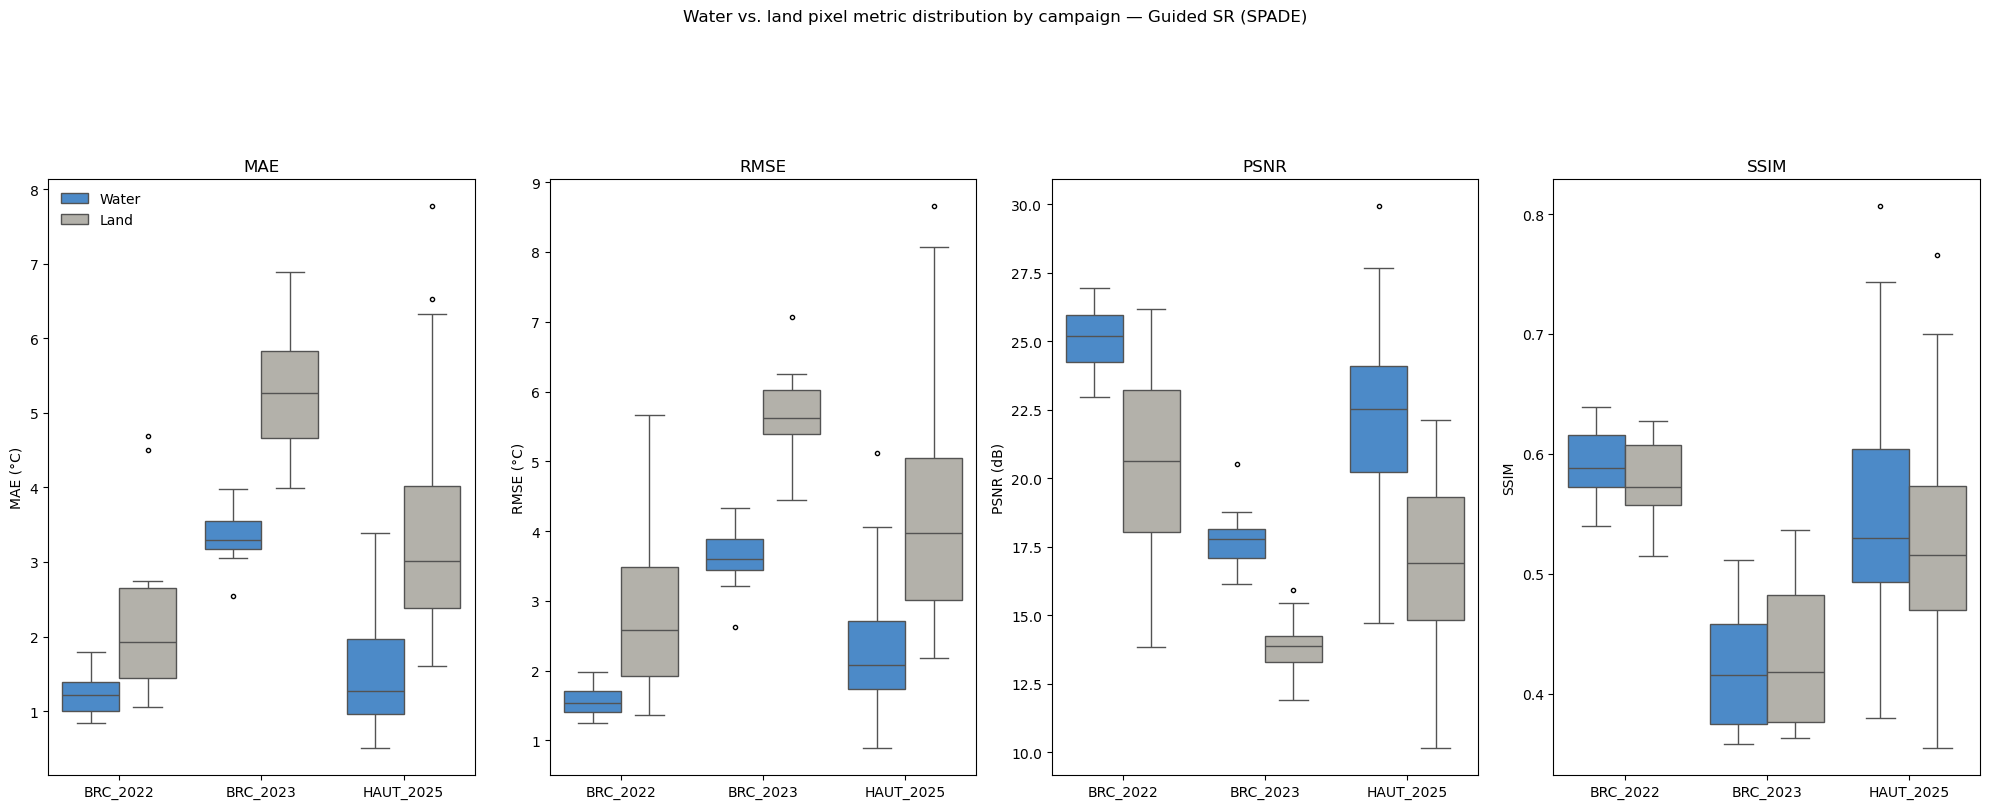

In [16]:
# reshape from wide (water_mae, land_mae, ...) to long format for hue-based grouping
df_long = pd.concat([
    df.assign(region="Water")[["campaign", "water_mae", "water_rmse", "water_psnr", "water_ssim"]]
      .rename(columns=lambda c: c.replace("water_", "")),
    df.assign(region="Land")[["campaign", "land_mae", "land_rmse", "land_psnr", "land_ssim"]]
      .rename(columns=lambda c: c.replace("land_", "")),
], keys=["Water", "Land"]).reset_index(level=0).rename(columns={"level_0": "region"})

metrics = ["mae", "rmse", "psnr", "ssim"]
labels  = ["MAE (°C)", "RMSE (°C)", "PSNR (dB)", "SSIM"]

fig, axes = plt.subplots(1, 4, figsize=(20, 7))
for i, (ax, metric, label) in enumerate(zip(axes, metrics, labels)):
    sns.boxplot(
        data=df_long, x="campaign", y=metric, hue="region", ax=ax,
        order=CAMPAIGN_ORDER, hue_order=["Water", "Land"],
        flierprops=dict(marker="o", markerfacecolor="none",
                         markeredgecolor="black", markersize=3),
        palette={"Water": "#378ADD", "Land": "#B4B2A9"}
    )
    ax.set_ylabel(label)
    ax.set_xlabel("")
    ax.set_title(label.split(" ")[0])
    ax.tick_params(axis="x")
    if i == 0:
        ax.legend(loc="upper left", frameon=False, title=None)
    else:
        ax.legend_.remove()

plt.suptitle("Water vs. land pixel metric distribution by campaign — Guided SR (SPADE)", y=1.15)
plt.savefig("spade_boxplot.png", dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()

### residual histograms

In [7]:
import pandas as pd

def extract_residuals(dataset, model_obj, region="water", model_name="Baseline", save_path=None):
    all_residuals = []
    all_sample_ids = []

    for idx, sample in enumerate(dataset):
        hr_mask = sample["hr_mask"].squeeze(0)
        water_mask = sample["water_mask"].squeeze(0)

        # -----------------------------
        # Region mask
        # -----------------------------
        if region == "water":
            region_mask = (hr_mask > 0.5) & (water_mask > 0.5)
        elif region == "non_water":
            region_mask = (hr_mask > 0.5) & (water_mask <= 0.5)
        else:
            raise ValueError("region must be 'water' or 'non_water'")

        if region_mask.sum() < 10:
            continue

        # Model inference
        sr_np = run_inference(model_obj, sample)

        # Denormalize HR
        hr_np = ( sample["hr"][0].numpy() * HR_STD) + HR_MEAN

        # Valid pixels
        region_mask = region_mask.numpy()
        valid = ( region_mask & np.isfinite(hr_np) & np.isfinite(sr_np))

        if valid.sum() == 0:
            continue

        # Residual
        residual = sr_np[valid] - hr_np[valid]

        all_residuals.append(residual)
        all_sample_ids.extend([idx] * len(residual))

    # Flatten
    residual_v = np.concatenate(all_residuals)
    sample_ids_v = np.array(all_sample_ids)

    # Save
    if save_path is None: save_path = ( f"{region}_residuals_" f"{model_name.lower().replace(' ', '_')}.npz")

    np.savez_compressed(
        save_path,
        sample_id=sample_ids_v,
        residual=residual_v,
        model_name=model_name,
        region=region
    )

    print(f"Saved {len(residual_v):,} " f"{region} residuals for {model_name}")

    return pd.DataFrame({
        "sample_id": sample_ids_v,
        "residual": residual_v,
        "model": model_name,
        "region": region
    })

In [8]:
water = extract_residuals(
    test_ds,
    model,
    region="water",
    model_name="spade",
    save_path="spade_wat_res.npz"
)

nonwater = extract_residuals(
    test_ds,
    model,
    region="non_water",
    model_name="spade",
    save_path="spade_nonwat_res.npz"
)

Saved 440,308 water residuals for spade
Saved 935,467 non_water residuals for spade


In [5]:
import numpy as np
import pandas as pd

def load_residual_npz(path):
    data = np.load(path, allow_pickle=True)

    return pd.DataFrame({
        "sample_id": data["sample_id"],
        "residual": data["residual"],
        "model": str(data["model_name"]),
        "region": str(data["region"])
    })

baseline_water = load_residual_npz(BASE / "results/stats/base_wt_res.npz")
baseline_nonwater = load_residual_npz(BASE / "results/stats/base_nw_res.npz")

spade_water = load_residual_npz(BASE / "results/stats/spade_wat_res.npz")
spade_nonwater = load_residual_npz(BASE / "results/stats/spade_nonwat_res.npz")

residual_df = pd.concat(
    [
        baseline_water,
        baseline_nonwater,
        spade_water,
        spade_nonwater,
    ],
    ignore_index=True,
)

print(residual_df.head())

   sample_id  residual     model region
0          0  1.283829  baseline  water
1          0  2.352612  baseline  water
2          0  1.504307  baseline  water
3          0  1.733799  baseline  water
4          0  1.786291  baseline  water


Water      | Baseline  | Bias = +1.67 °C | SD = 3.23 °C
Water      | SPADE     | Bias = +0.15 °C | SD = 2.63 °C
Non-water  | Baseline  | Bias = +0.52 °C | SD = 5.40 °C
Non-water  | SPADE     | Bias = +1.63 °C | SD = 4.45 °C


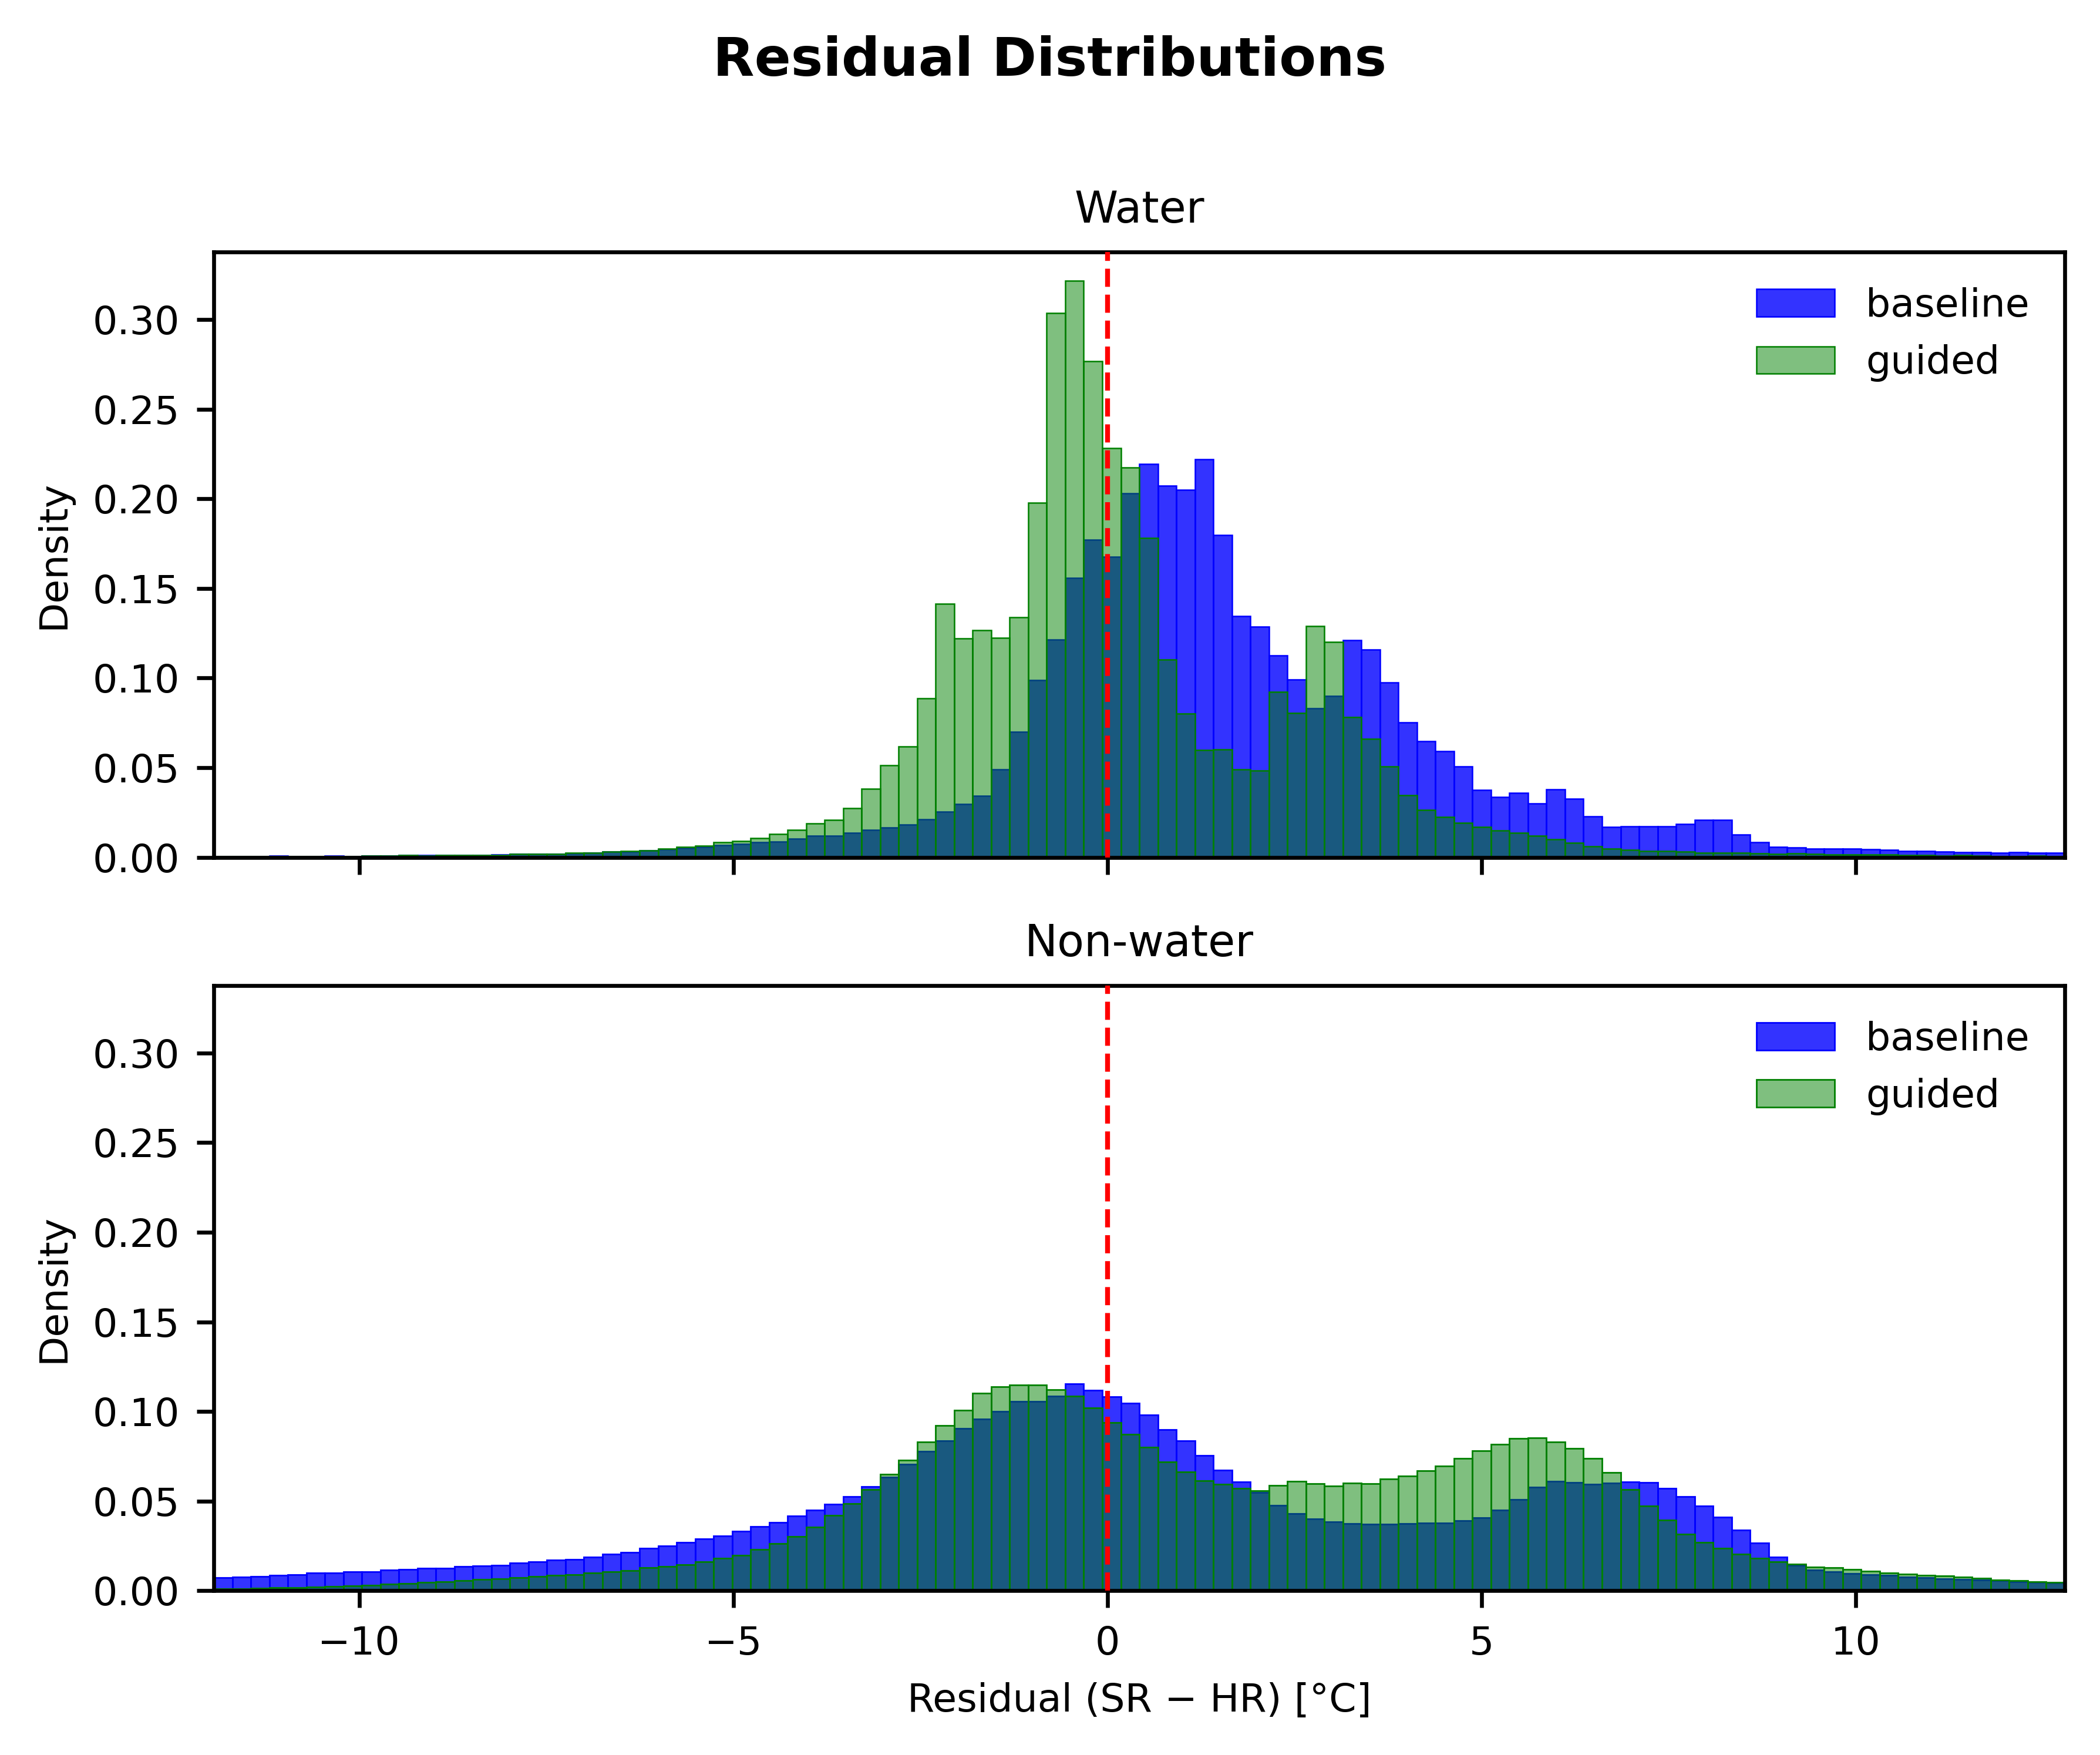

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------
# Common plotting range
# ------------------------------------------------

all_residuals = residual_df["residual"].to_numpy()

xmin = np.percentile(all_residuals, 1)
xmax = np.percentile(all_residuals, 99)

padding = 0.5
xmin -= padding
xmax += padding

bins = np.linspace(xmin, xmax, 101)


# ------------------------------------------------
# Plot style
# ------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8
})

colors = {
    "baseline": "blue",
    "spade": "green",
}

regions = [
    ("Water", "water"),
    ("Non-water", "non_water"),
]


# ------------------------------------------------
# Figure
# ------------------------------------------------

fig, axes = plt.subplots(
    2, 1,
    figsize=(6, 5),
    sharex=True,
    sharey=True,
    dpi=600
)


for ax, (title, region) in zip(axes, regions):

    region_df = residual_df[
        residual_df["region"] == region
    ]

    # ------------------------------------------------
    # Baseline — plot first (darker/background)
    # ------------------------------------------------

    residuals = region_df.loc[
        region_df["model"] == "baseline",
        "residual"
    ]

    sns.histplot(
        residuals,
        bins=bins,
        stat="density",
        kde=False,
        color=colors["baseline"],
        alpha=0.8,
        edgecolor=colors["baseline"],
        # linewidth=0.2,
        ax=ax,
        label="baseline"
    )

    bias = residuals.mean()
    std = residuals.std()

    print(
        f"{title:10s} | "
        f"{'Baseline':9s} | "
        f"Bias = {bias:+.2f} °C | "
        f"SD = {std:.2f} °C"
    )


    # ------------------------------------------------
    # SPADE — lighter/foreground
    # ------------------------------------------------

    residuals = region_df.loc[
        region_df["model"] == "spade",
        "residual"
    ]

    sns.histplot(
        residuals,
        bins=bins,
        stat="density",
        kde=False,
        color=colors["spade"],
        alpha=0.50,
        edgecolor=colors["spade"],
        # linewidth=0.2,
        ax=ax,
        label="guided"
    )

    bias = residuals.mean()
    std = residuals.std()

    print(
        f"{title:10s} | "
        f"{'SPADE':9s} | "
        f"Bias = {bias:+.2f} °C | "
        f"SD = {std:.2f} °C"
    )


    # ------------------------------------------------
    # Zero residual reference
    # ------------------------------------------------

    ax.axvline(
        0,
        color="red",
        linestyle="--",
        linewidth=1,
        zorder=10
    )

    ax.set_title(
        title,
        fontsize=9
    )

    ax.set_ylabel("Density")

    ax.set_xlim(
        xmin,
        xmax
    )

    ax.legend(
        frameon=False,
        fontsize=8
    )


# ------------------------------------------------
# Labels
# ------------------------------------------------

axes[-1].set_xlabel(
    "Residual (SR − HR) [°C]"
)

fig.suptitle(
    "Residual Distributions",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

# plt.savefig(
#     "residual_histograms_water_nonwater.png",
#     dpi=600,
#     bbox_inches="tight",
#     pad_inches=0.05
# )

plt.show()

In [28]:
summary = residual_df.groupby("model")["residual"].agg(
    ["mean", "median", "std", "min", "max"]
)

print(summary)

               mean    median       std        min        max
model                                                        
Aux_input -0.070718 -0.898070  3.734697 -47.464058  32.803535
Baseline   1.674076  1.239504  3.234496 -47.869213  29.386023
spade      0.145236 -0.201632  2.629445 -47.700226  25.467491


### Data distribution shift of tests vs train

In [1]:
import os
import numpy as np
import rasterio

# --- Function to Extract Pixels from Campaigns ---
def extract_pixels(data_dir, campaigns, output_filename):
    total_pixels = []
    water_pixels = []
    
    for p in campaigns:
        path = os.path.join(data_dir, "HR_downsampled", f"{p}.tif")
        # Direct folder matching your setup
        aux_path = os.path.join(data_dir, "AUX", "water_masks", f"{p}_water_mask.tif") 
        
        if os.path.exists(path) and os.path.exists(aux_path):
            print(f"[Processing] {p}...")
            with rasterio.open(path) as src:
                img = src.read(1).astype(float)
                # Base mask to drop NaNs and padding zeros
                valid_base = (np.isfinite(img) & (img != src.nodata))  

            with rasterio.open(aux_path) as src_aux:
                mask_img = src_aux.read(1)
                
            # Total pixels (Land + Water inside valid flight swath)
            total_pixels.extend(img[valid_base].flatten())
            
            # Water-only pixels (Where base is valid AND mask indicates water)
            # Adjust '== 1' if your water mask uses a different class integer
            water_mask = valid_base & (mask_img == 1)
            water_pixels.extend(img[water_mask].flatten())
            
    # Save arrays as a single compressed file
    np.savez_compressed(output_filename, total=np.array(total_pixels), water=np.array(water_pixels))
    print(f"Saved arrays to cache file: {output_filename}")

# --- Configurations ---
DATA_DIR = "/share/home/e2406751/Superresolution-TIR/data"
TRAIN = ["BAS_2025", "DZM_2013", "DZM_2014", "DZM_2019", "DZM_2023", "PDR_2013", "PDR_2014", "PDR_2023"]
TEST = ["BRC_2022", "BRC_2023", "HAUT_2025"]

# Run the extraction once
print("Extracting Train/Val...")
extract_pixels(DATA_DIR, TRAIN, "train_pixels.npz")

print("\nExtracting Test...")
extract_pixels(DATA_DIR, TEST, "test_pixels.npz")

Extracting Train/Val...
[Processing] BAS_2025...
[Processing] DZM_2013...
[Processing] DZM_2014...
[Processing] DZM_2019...
[Processing] DZM_2023...
[Processing] PDR_2013...
[Processing] PDR_2014...
[Processing] PDR_2023...
Saved arrays to cache file: train_pixels.npz

Extracting Test...
[Processing] BRC_2022...
[Processing] BRC_2023...
[Processing] HAUT_2025...
Saved arrays to cache file: test_pixels.npz


In [1]:
import os
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

## Load cached arrays 
train_cache = np.load("/share/home/e2406751/Superresolution-TIR/data/train_pixels.npz")
test_cache = np.load("/share/home/e2406751/Superresolution-TIR/data/test_pixels.npz")

train_total, train_water = train_cache['total'], train_cache['water']
test_total, test_water = test_cache['total'], test_cache['water']

In [18]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Load cached arrays
train_data = np.load("/share/home/e2406751/Superresolution-TIR/data/train_pixels.npz")
test_data  = np.load("/share/home/e2406751/Superresolution-TIR/data/test_pixels.npz")

def run_tests(train, test, label):
    print(f"\n ---- {label} ------ ")
    print(f"  Train — n={len(train):,}, mean={train.mean():.2f}°C, "
          f"std={train.std():.2f}°C, median={np.median(train):.2f}°C")
    print(f"  Test  — n={len(test):,},  mean={test.mean():.2f}°C, "
          f"std={test.std():.2f}°C, median={np.median(test):.2f}°C")
    
    def interpret(p):
        if p < 0.05:
            return "p < 0.05"
        else:
            return f"p = {p:.3e}"
        
    # Welch t-test — does not assume equal variance
    t_test= stats.ttest_ind(train, test, equal_var=False, alternative='two-sided')
    print(f"\nWelch T-test:  t={t_test.statistic:.4f}, {interpret(t_test.pvalue)}")
    print("T-test: ", t_test)
 
    ks_test = stats.ks_2samp(train, test, alternative='two-sided')
    print(f"\n  KS test: D={ks_test.statistic:.4f}, {interpret(ks_test.pvalue)}")
    print("KS test: ", ks_test)

    return t_test.statistic, t_test.pvalue, ks_test.statistic, ks_test.pvalue

# Run both
run_tests(train_data["total"], test_data["total"], "All Valid Pixels")
run_tests(train_data["water"], test_data["water"], "Water Pixels Only")


 ---- All Valid Pixels ------ 
  Train — n=3,751,190, mean=30.56°C, std=6.25°C, median=28.86°C
  Test  — n=1,407,163,  mean=29.25°C, std=5.92°C, median=28.92°C

Welch T-test:  t=220.6920, p < 0.05
T-test:  TtestResult(statistic=220.69202929877494, pvalue=0.0, df=2653968.421823688)

  KS test: D=0.1992, p < 0.05
KS test:  KstestResult(statistic=0.1991996562916495, pvalue=0.0, statistic_location=24.79605484008789, statistic_sign=-1)

 ---- Water Pixels Only ------ 
  Train — n=1,227,086, mean=25.39°C, std=2.93°C, median=25.07°C
  Test  — n=448,653,  mean=25.00°C, std=2.98°C, median=24.39°C

Welch T-test:  t=74.1305, p < 0.05
T-test:  TtestResult(statistic=74.1305215856395, pvalue=0.0, df=787323.604831239)

  KS test: D=0.2786, p < 0.05
KS test:  KstestResult(statistic=0.2786435831735567, pvalue=0.0, statistic_location=24.63178253173828, statistic_sign=-1)


(74.1305215856395, 0.0, 0.2786435831735567, 0.0)

Total Landscape: We see a massive mean environment divergence ($t = 220.69$) and a clear structural distribution shift ($D = 0.199, p \approx 0$). This mathematically confirms that the overall background thermal context shifts radically between splits due to the low-vs-high elevation topography.

Water Channel Only: The mean divergence drops drastically ($t = 74.13$), showing the water channels track much closer together in absolute temperature. However, the KS test ($D = 0.278$) catches a structural shape mismatch peaking right at $24.6^\circ\text{C}$, indicating that the high-elevation test catchment compresses or skews the water temperature distribution compared to the lowland training baseline."

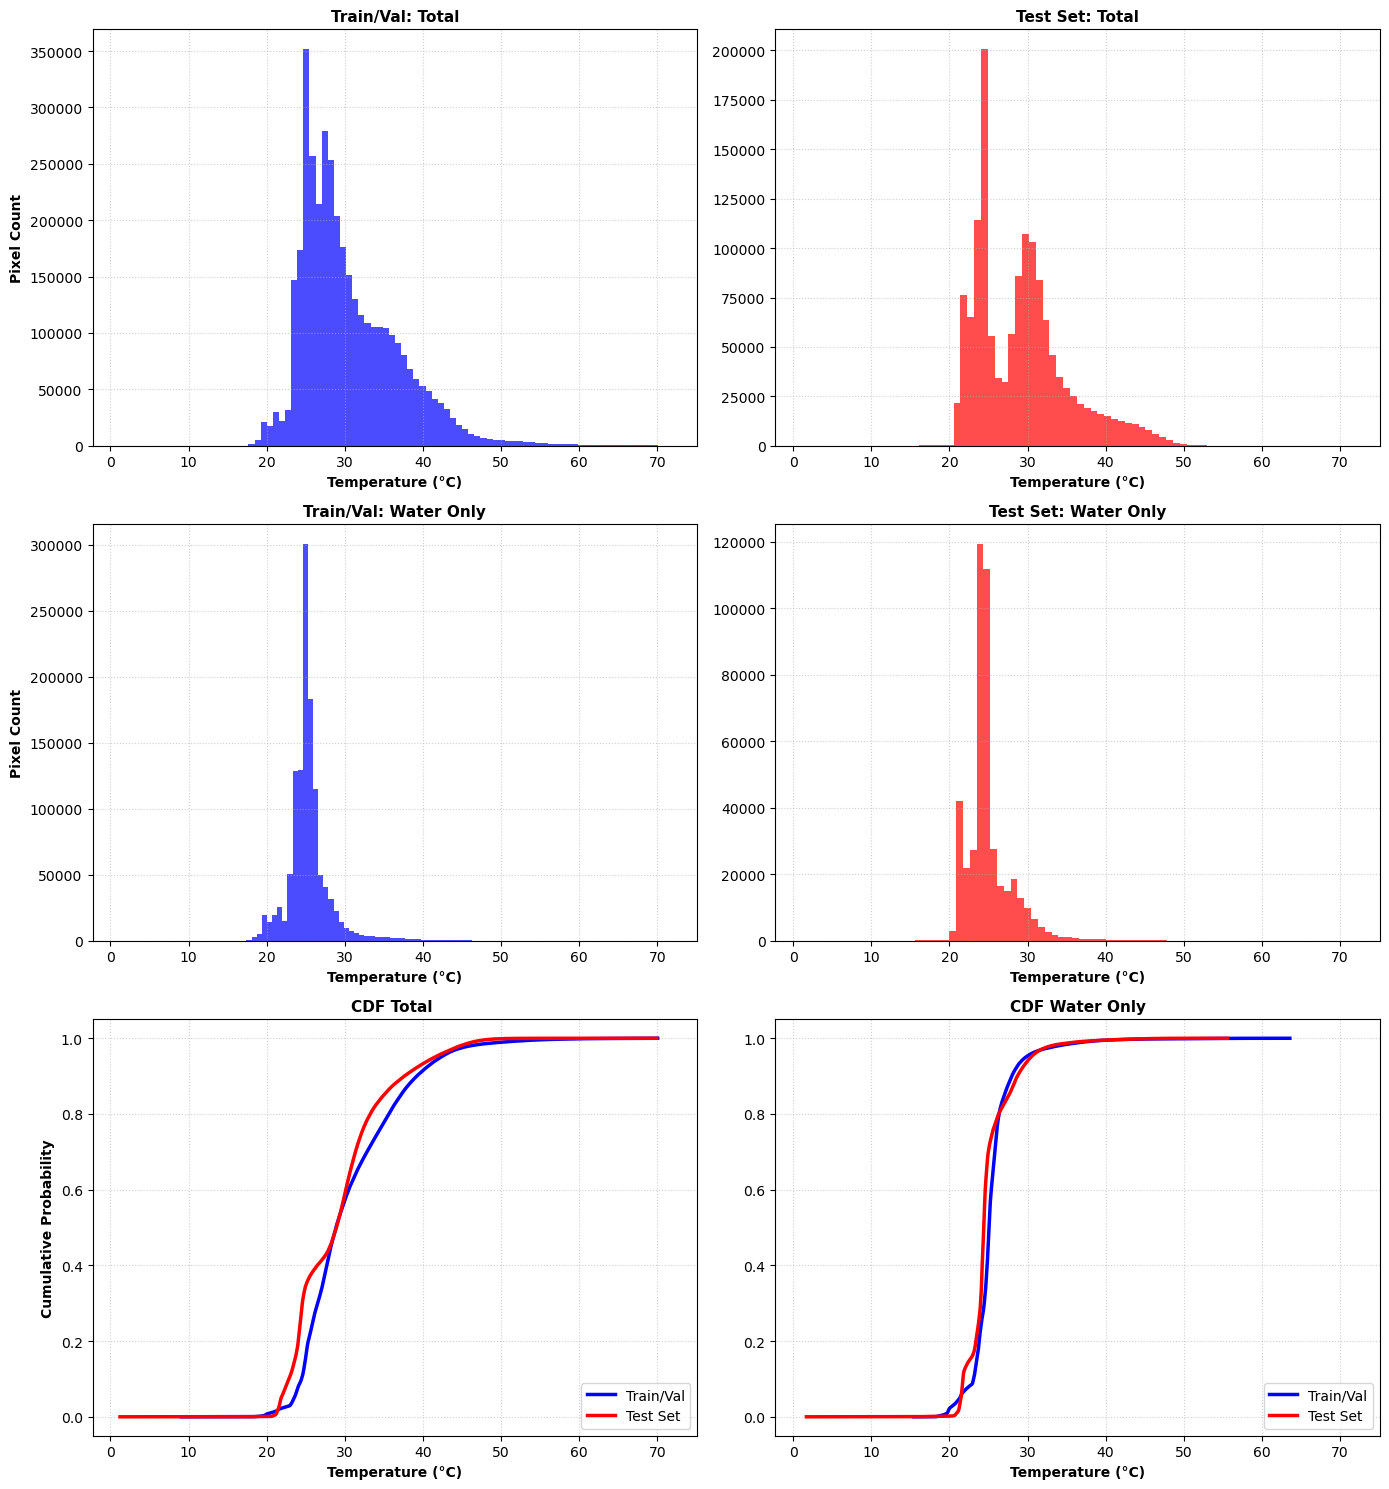

In [7]:
# trimming outliers for better visualization
def trim_outliers(data):
    low = np.percentile(data, 0.5)
    high = np.percentile(data, 99.5)
    return data[(data >= low) & (data <= high)], low, high

train_total_trimmed, tr_tot_l, tr_tot_h = trim_outliers(train_total)
test_total_trimmed, te_tot_l, te_tot_h = trim_outliers(test_total)
train_water_trimmed, tr_wat_l, tr_wat_h = trim_outliers(train_water)
test_water_trimmed, te_wat_l, te_wat_h = trim_outliers(test_water)

# Shared axis ranges across train/test columns
tot_xlim = (min(tr_tot_l, te_tot_l) - 1, max(tr_tot_h, te_tot_h) + 1)
wat_xlim = (min(tr_wat_l, te_wat_l) - 1, max(tr_wat_h, te_wat_h) + 1)

# plotting
# fig, axes = plt.subplots(3, 2, figsize=(14, 14))
# This automatically forces every row and column to share the exact same x-axis bounds
fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharex=True)

#  Histograms Only (Total Landscape)
axes[0, 0].hist(train_total, bins=80, color='blue', alpha=0.7)
axes[0, 0].set_title("Train/Val: Total", fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel("Pixel Count", fontweight='bold')
# axes[0, 0].set_xlim(tot_xlim)

axes[0, 1].hist(test_total, bins=80, color='red', alpha=0.7)
axes[0, 1].set_title("Test Set: Total", fontsize=11, fontweight='bold')
# axes[0, 1].set_xlim(tot_xlim)

# Histograms Only (Water Channel Only)
axes[1, 0].hist(train_water, bins=80, color='blue', alpha=0.7)
axes[1, 0].set_title("Train/Val: Water Only", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("Pixel Count", fontweight='bold')
# axes[1, 0].set_xlim(wat_xlim)

axes[1, 1].hist(test_water, bins=80, color='red', alpha=0.7)
axes[1, 1].set_title("Test Set: Water Only", fontsize=11, fontweight='bold')
# axes[1, 1].set_xlim(wat_xlim)

# CDF Line Overlay Plots
def plot_cdf_line(ax, data, color, label):
    sorted_data = np.sort(data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    # Stride calculation for lighter memory usage when drawing lines
    if len(sorted_data) > 10000:
        stride = len(sorted_data) // 10000
        sorted_data, y_vals = sorted_data[::stride], y_vals[::stride]
    ax.plot(sorted_data, y_vals, color=color, linewidth=2.5, label=label)

# CDF Left Panel: Total Landscape Overlay
plot_cdf_line(axes[2, 0], train_total, color='blue', label='Train/Val')
plot_cdf_line(axes[2, 0], test_total, color='red', label='Test Set')
axes[2, 0].set_title("CDF Total ", fontsize=11, fontweight='bold')
axes[2, 0].set_xlabel("Temperature (°C)", fontweight='bold')
axes[2, 0].set_ylabel("Cumulative Probability", fontweight='bold')
# axes[2, 0].set_xlim(tot_xlim)
axes[2, 0].legend(loc='lower right')

# CDF Right Panel: Water Channel Overlay
plot_cdf_line(axes[2, 1], train_water, color='blue', label='Train/Val')
plot_cdf_line(axes[2, 1], test_water, color='red', label='Test Set')
axes[2, 1].set_title("CDF Water Only", fontsize=11, fontweight='bold')
axes[2, 1].set_xlabel("Temperature (°C)", fontweight='bold')
# axes[2, 1].set_xlim(wat_xlim)
axes[2, 1].legend(loc='lower right')

# Apply grid layout to all panels simultaneously
for ax in axes.flatten():
    ax.tick_params(labelbottom=True)
    ax.set_xlabel("Temperature (°C)", fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

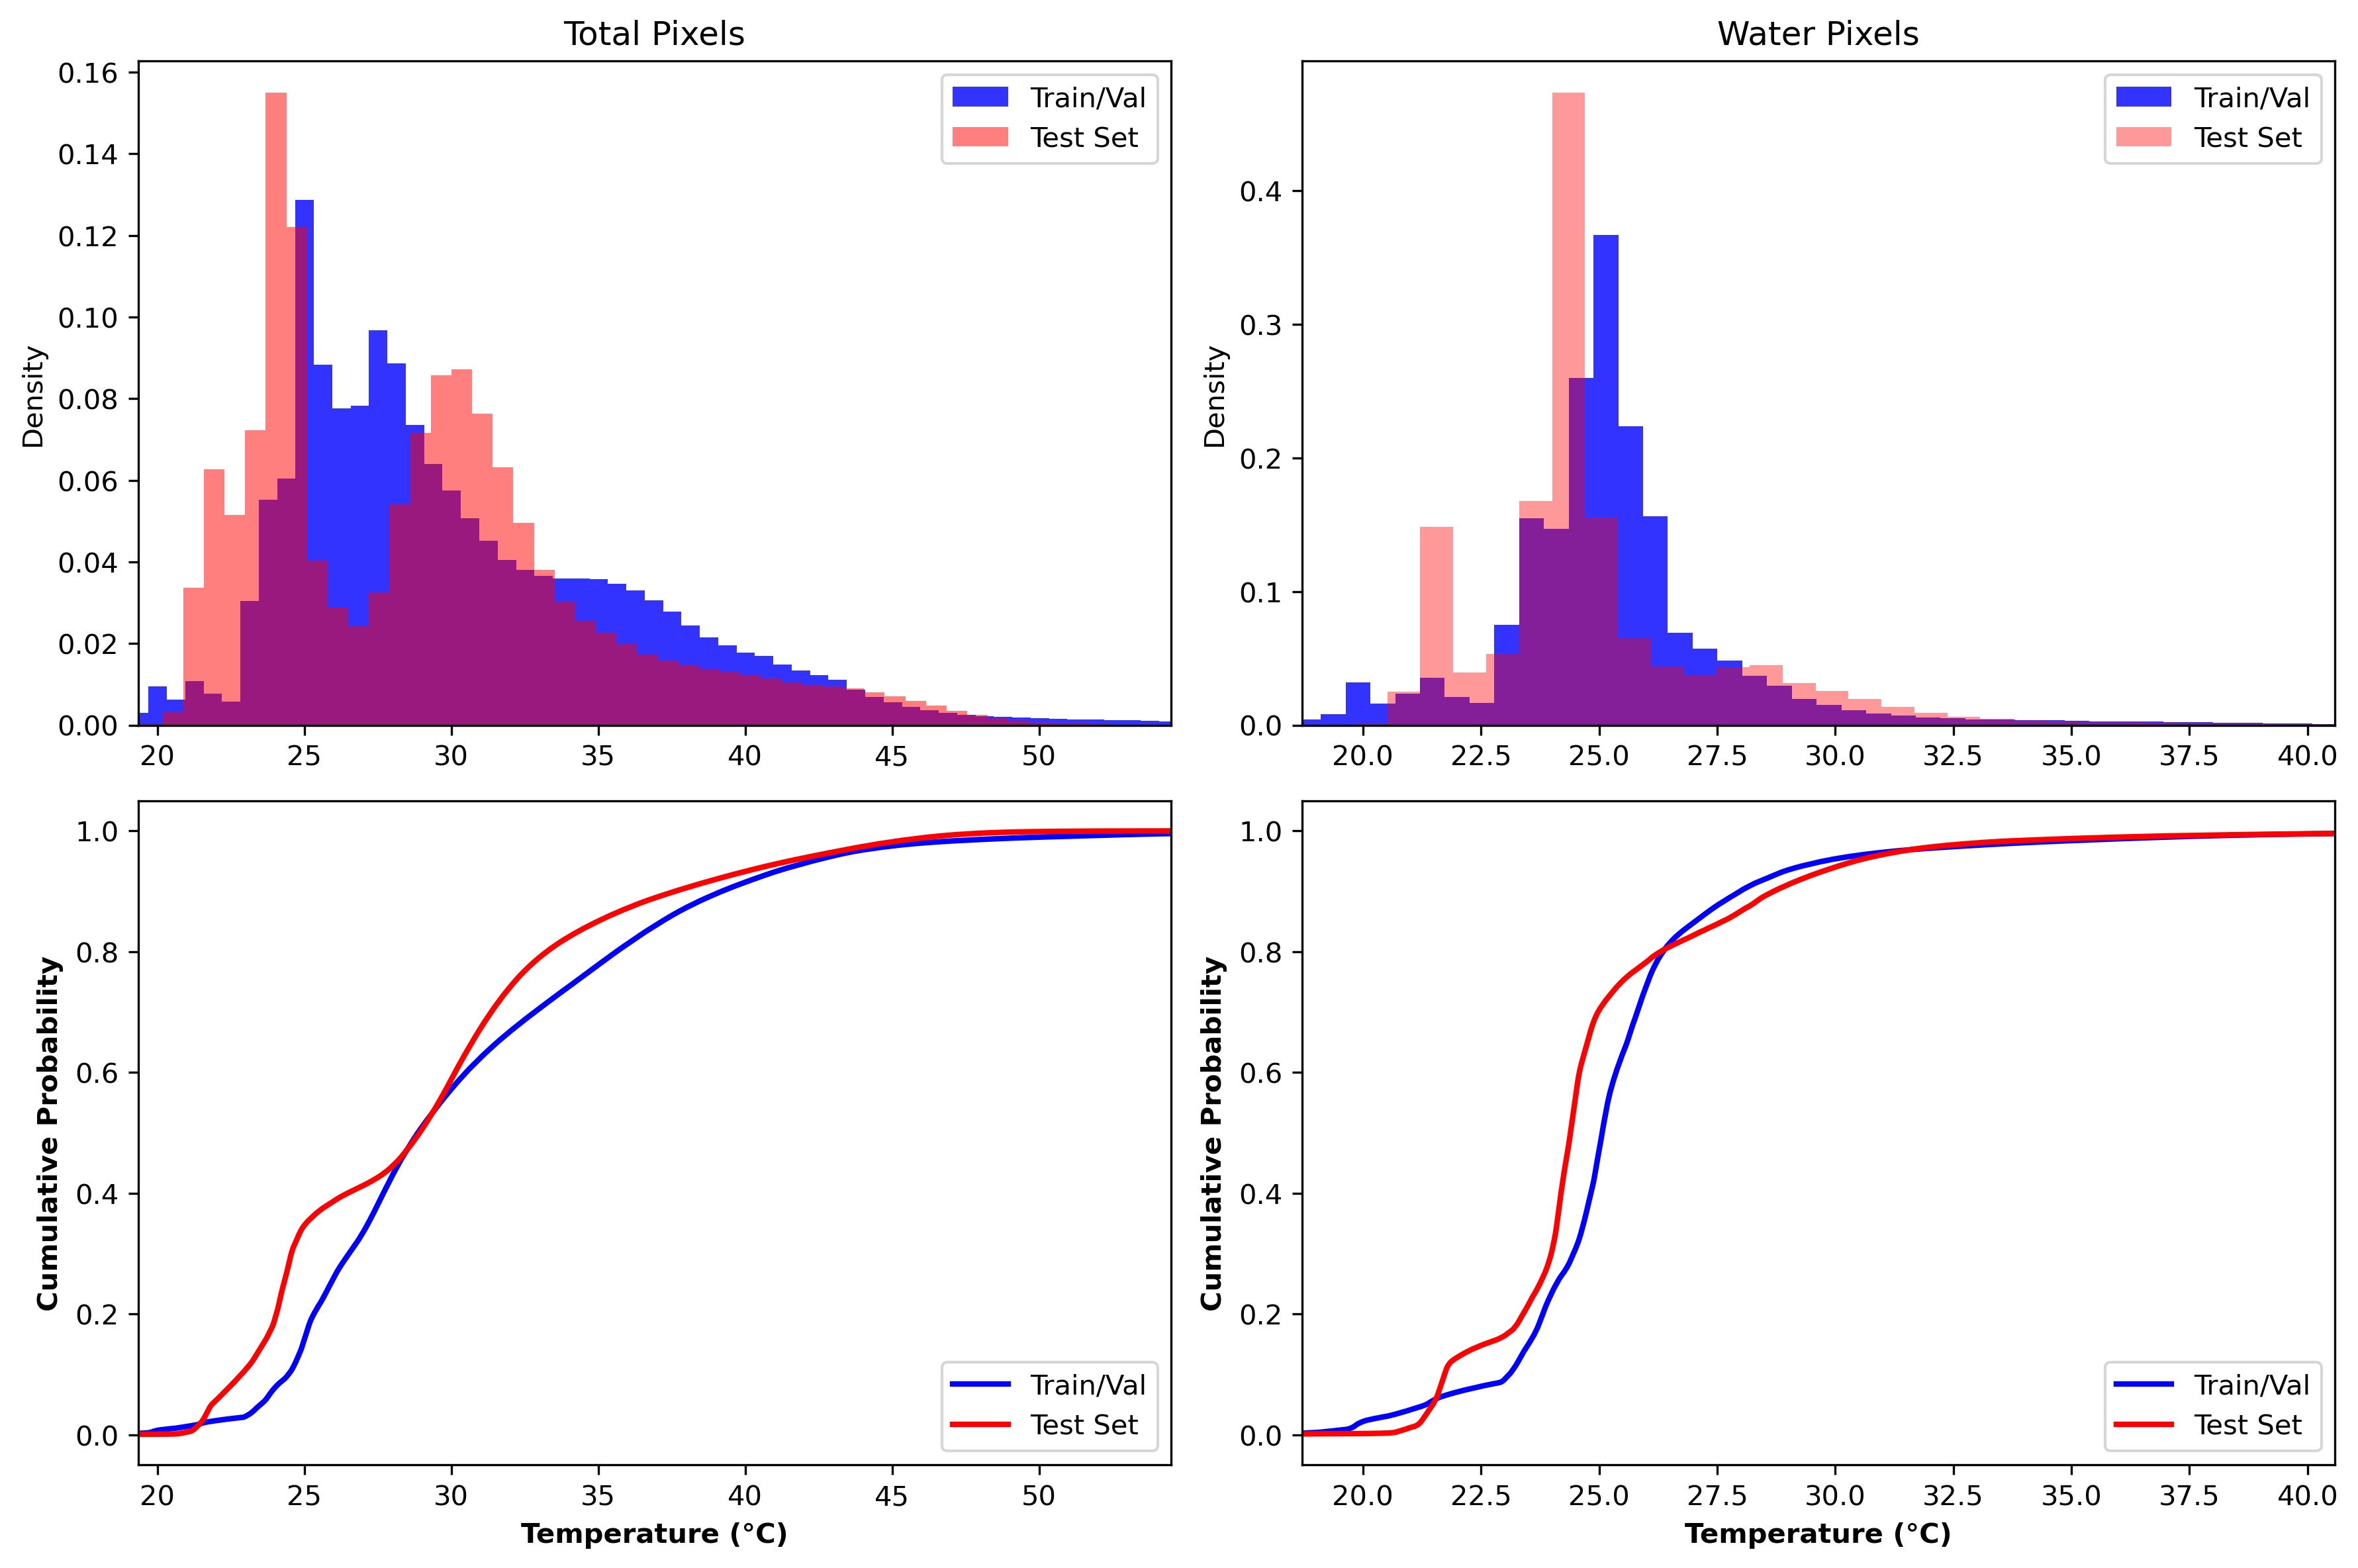

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Trimming helper for clean axis bounds
def get_percentile_bounds(data, p_low=0.5, p_high=99.5):
    return np.percentile(data, [p_low, p_high])

# Compute dynamic x-axis bounds per category
tr_tot_l, tr_tot_h = get_percentile_bounds(train_total)
te_tot_l, te_tot_h = get_percentile_bounds(test_total)
tr_wat_l, tr_wat_h = get_percentile_bounds(train_water)
te_wat_l, te_wat_h = get_percentile_bounds(test_water)

tot_xlim = (min(tr_tot_l, te_tot_l) - 0.5, max(tr_tot_h, te_tot_h) + 0.5)
wat_xlim = (min(tr_wat_l, te_wat_l) - 0.5, max(tr_wat_h, te_wat_h) + 0.5)

# 2. Setup 2x2 Grid
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 10})
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=300)

# ── ROW 0: Probability Density Histograms ──

# Total Landscape (Train vs Test Overlaid)
axes[0, 0].hist(train_total, bins=100, density=True, color='blue', alpha=0.8, label='Train/Val')
axes[0, 0].hist(test_total, bins=100, density=True, color='red', alpha=0.5, label='Test Set')
axes[0, 0].set_title("Total Pixels")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_xlim(tot_xlim)
axes[0, 0].legend()

# Water Channel Only (Train vs Test Overlaid)
axes[0, 1].hist(train_water, bins=100, density=True, color='blue', alpha=0.8, label='Train/Val')
axes[0, 1].hist(test_water, bins=100, density=True, color='red', alpha=0.4, label='Test Set')
axes[0, 1].set_title("Water Pixels")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_xlim(wat_xlim)
axes[0, 1].legend()

# ── ROW 1: Cumulative Distribution Functions (CDFs) ──

def plot_cdf_line(ax, data, color, label):
    sorted_data = np.sort(data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    if len(sorted_data) > 10000:
        stride = len(sorted_data) // 10000
        sorted_data, y_vals = sorted_data[::stride], y_vals[::stride]
    ax.plot(sorted_data, y_vals, color=color, linewidth=2.0, label=label)

# Total Landscape CDF
plot_cdf_line(axes[1, 0], train_total, color='blue', label='Train/Val')
plot_cdf_line(axes[1, 0], test_total, color='red', label='Test Set')
# axes[1, 0].set_title("Total CDF", fontweight='bold')
axes[1, 0].set_xlabel("Temperature (°C)", fontweight='bold')
axes[1, 0].set_ylabel("Cumulative Probability", fontweight='bold')
axes[1, 0].set_xlim(tot_xlim)
axes[1, 0].legend(loc='lower right')

# Water Channel CDF
plot_cdf_line(axes[1, 1], train_water, color='blue', label='Train/Val')
plot_cdf_line(axes[1, 1], test_water, color='red', label='Test Set')
# axes[1, 1].set_title("Water CDF", fontweight='bold')
axes[1, 1].set_xlabel("Temperature (°C)", fontweight='bold')
axes[1, 1].set_ylabel("Cumulative Probability", fontweight='bold')
axes[1, 1].set_xlim(wat_xlim)
axes[1, 1].legend(loc='lower right')

# Global formatting
# for ax in axes.flatten():
#     ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("/share/home/e2406751/Superresolution-TIR/results/stats/train-test_data_dist.png", dpi=600, bbox_inches='tight')
plt.show()

[INFO] Gathering DEM elevation profiles from the last AUX band...
[WARNING] File not found: /share/home/e2406751/Superresolution-TIR/data/AUX/auxiliary/BRC_2024_aux.tif


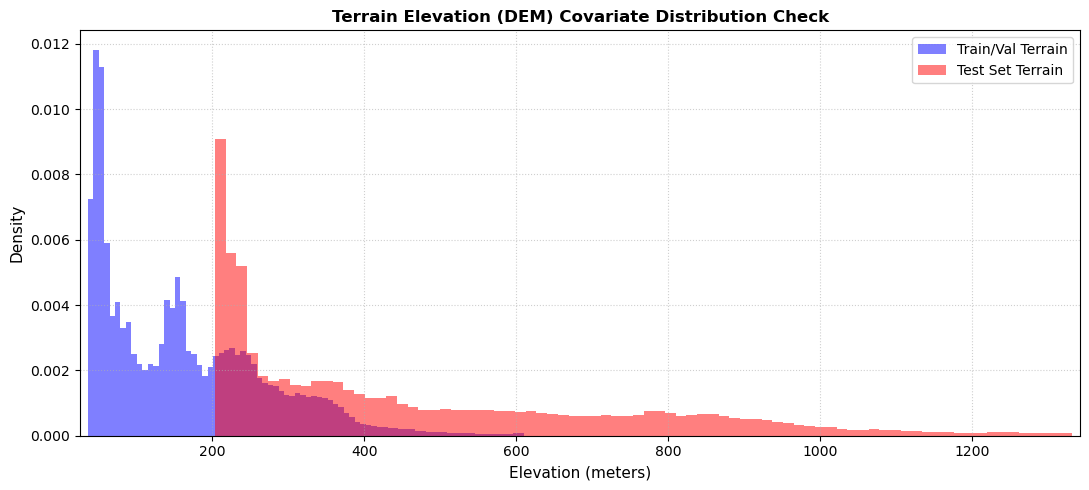

In [ ]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

def extract_dem_distributions(data_dir, split_prefixes):
    elevation_list = []
    
    for prefix in split_prefixes:
        # Using the exact auxiliary subdirectory path structure from your setup
        aux_path = os.path.join(data_dir, "AUX", "auxiliary", f"{prefix}_aux.tif") 
        
        if not os.path.exists(aux_path):
            print(f"[WARNING] File not found: {aux_path}")
            continue
            
        with rasterio.open(aux_path) as src_aux:
            # Dynamically target the last band (DEM)
            dem_band_idx = src_aux.count
            dem_img = src_aux.read(dem_band_idx).astype(float)
            aux_nodata = src_aux.nodatavals[dem_band_idx - 1]
            
            # Read band 1 (water mask) to isolate the valid flight swath boundaries
            mask_band = src_aux.read(1)
            
        # Filter the DEM array using its own native grid dimensions
        if aux_nodata is not None:
            is_valid_terrain = (dem_img != aux_nodata) & (~np.isnan(dem_img))
        else:
            is_valid_terrain = (dem_img != 0) & (~np.isnan(dem_img))
            
        # Ensure we stay within the actual flight mapping boundaries
        is_inside_swath = (mask_band >= 0) 
        final_valid_mask = is_valid_terrain & is_inside_swath
        
        # Safely extract elevations 
        valid_elevations = dem_img[final_valid_mask]
        elevation_list.extend(valid_elevations.flatten())
        
    return np.array(elevation_list)

# --- Path Configuration ---
DATA_DIR = "/share/home/e2406751/Superresolution-TIR/data" 
TRAIN_CAMPAIGNS = ["BAS_2025", "DZM_2013", "DZM_2014", "DZM_2019", "DZM_2023", "PDR_2013", "PDR_2014", "PDR_2023"] 
TEST_CAMPAIGNS = ["BRC_2022", "BRC_2023", "HAUT_2025"]

print("[INFO] Gathering DEM elevation profiles from the last AUX band...")
train_dem = extract_dem_distributions(DATA_DIR, TRAIN_CAMPAIGNS)
test_dem = extract_dem_distributions(DATA_DIR, TEST_CAMPAIGNS)

# --- Apply Two-Sided Cap to Ignore Outliers/Background Padding ---
def trim_terrain(data):
    if len(data) == 0:
        return data, 0, 100
    low = np.percentile(data, 0.5)
    high = np.percentile(data, 99.5)
    return data[(data >= low) & (data <= high)], low, high

train_dem_trimmed, tr_low, tr_high = trim_terrain(train_dem)
test_dem_trimmed, te_low, te_high = trim_terrain(test_dem)

# --- Plot the Terrain Covariate Comparison ---
plt.figure(figsize=(11, 5))

# Plotting as Density Histograms so the scales match even if pixel counts differ
if len(train_dem_trimmed) > 0:
    plt.hist(train_dem_trimmed, bins=80, color='blue', alpha=0.5, density=True, label='Train/Val Terrain')
if len(test_dem_trimmed) > 0:
    plt.hist(test_dem_trimmed, bins=80, color='red', alpha=0.5, density=True, label='Test Set Terrain')

plt.title("Terrain Elevation (DEM) Covariate Distribution Check", fontsize=12, fontweight='bold')
plt.xlabel("Elevation (meters)", fontsize=11)
plt.ylabel("Density", fontsize=11)

# Set horizontal limits safely around data bounds
x_min = min(tr_low, te_low) - 10
x_max = max(tr_high, te_high) + 10
plt.xlim(x_min, x_max)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Inference per campaign

In [4]:
from scripts.evaluation.inference import run_inference_pipeline

df = run_inference_pipeline(
    model=model,
    splits=["test"],
    patches_dir=BASE / "data/processed/patches",
    metadata_path=BASE / "data/processed/patches/metadata.json",
    stats_path=BASE / "data/processed/patches/stats.json",
    output_csv=BASE / "results/per_patch_metrics.csv",
    output_npz=BASE / "results/inference_raw.npz",
    ) 


── Processing Split: test ──


test:   6%|▋         | 4/64 [00:00<00:04, 14.51it/s]

test: 100%|██████████| 64/64 [00:03<00:00, 16.08it/s]



Saved metadata registry → /share/home/e2406751/Superresolution-TIR/results/per_patch_metrics.csv
Saved complete inference tensors → /share/home/e2406751/Superresolution-TIR/results/inference_raw.npz


In [5]:
import numpy as np
import pandas as pd

df = pd.read_csv(BASE / "results/per_patch_metrics.csv")
data = np.load(BASE / "results/inference_raw.npz", allow_pickle=True) 

sr = data["sr"]
hr = data["hr"]
lr = data["lr"]
hr_mask = data["hr_mask"]
water_mask = data["water_mask"]
row = data["row"]
col = data["col"]
campaigns = data["campaign"]
patch_ids = data["patch_id"]

In [10]:
# Convert masks to clean boolean arrays
hr_mask = data["hr_mask"] > 0.5
water_mask = data["water_mask"] > 0.5

# Isolate land and pure water regions
land_mask = hr_mask & (~water_mask)
pure_water_mask = hr_mask & water_mask

In [6]:
import json
from types import SimpleNamespace

# 1. Load stats
STATS_PATH = BASE / "data/processed/patches/stats.json"
with open(STATS_PATH) as f:
    stats_data = json.load(f)

# 2. Create an empty container that allows dot notation on the fly
module = SimpleNamespace()

# 3. Assign your training properties directly
module.DATA_RANGE = stats_data["hr_data_range"]
module.DATA_MIN   = stats_data["hr_percentiles"]["p1"]

print(f"Container ready: module.DATA_MIN = {module.DATA_MIN}")

Container ready: module.DATA_MIN = 20.763620376586914


In [7]:
import torch
from scripts.utils.metrics import compute_metrics

# Use GPU if available to speed up LPIPS, otherwise CPU works fine
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reshape arrays to 4D Tensors (B, C, H, W) as expected by the metric code
# .unsqueeze(1) adds the required channel dimension
sr_tensor = torch.from_numpy(sr).unsqueeze(1).to(device)
hr_tensor = torch.from_numpy(hr).unsqueeze(1).to(device)
hr_mask_tensor = torch.from_numpy(data["hr_mask"]).unsqueeze(1).to(device).float()
water_mask_tensor = torch.from_numpy(data["water_mask"]).unsqueeze(1).to(device).float()


patch_metrics_list = []

print("Computing structural and perceptual metrics patch-by-patch...")
for i in range(len(patch_ids)):
    with torch.no_grad():
        m_dict = compute_metrics(
            module=module,
            sr=sr_tensor[i:i+1],
            hr=hr_tensor[i:i+1],
            hr_mask=hr_mask_tensor[i:i+1],
            stage="test",
            water_mask=water_mask_tensor[i:i+1]
        )
    
    # Store patch identifier metadata
    row_metrics = {
        "patch_id": patch_ids[i],
        "campaign": campaigns[i]
    }
    
    # Extract structural scores out of PyTorch tensors safely
    for k, v in m_dict.items():
        row_metrics[k] = v.item() if (v is not None and torch.is_tensor(v)) else np.nan
        
    patch_metrics_list.append(row_metrics)

df_all_metrics = pd.DataFrame(patch_metrics_list)

Computing structural and perceptual metrics patch-by-patch...


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_

In [8]:
def aggregate_metrics(df_group):
    return pd.Series({
        "Water_MAE":  df_group["water_mae"].mean(),
        "Water_RMSE": df_group["water_rmse"].mean(),
        "Water_PSNR": df_group["water_psnr"].mean(),
        "Water_SSIM": df_group["water_ssim"].mean(),
        "Water_LPIPS":df_group["water_lpips"].mean(),
        
        "Land_MAE":   df_group["land_mae"].mean(),
        "Land_RMSE":  df_group["land_rmse"].mean(),
        "Land_PSNR":  df_group["land_psnr"].mean(),
        "Land_SSIM":  df_group["land_ssim"].mean(),
        "Land_LPIPS": df_group["land_lpips"].mean(),
    })

# Campaign Summaries
df_campaign_summary = df_all_metrics.groupby("campaign", as_index=False).apply(aggregate_metrics)
print("\n=== PERFORMANCE SUMMARY PER CAMPAIGN ===")
print(df_campaign_summary.to_markdown(index=False))

# Total Combined Test Set Summary
df_total_summary = aggregate_metrics(df_all_metrics).to_frame().T
df_total_summary.insert(0, "campaign", "TOTAL TEST SET")
print("\n=== GLOBAL TEST SET SUMMARY ===")
print(df_total_summary.to_markdown(index=False))


=== PERFORMANCE SUMMARY PER CAMPAIGN ===
| campaign   |   Water_MAE |   Water_RMSE |   Water_PSNR |   Water_SSIM |   Water_LPIPS |   Land_MAE |   Land_RMSE |   Land_PSNR |   Land_SSIM |   Land_LPIPS |
|:-----------|------------:|-------------:|-------------:|-------------:|--------------:|-----------:|------------:|------------:|------------:|-------------:|
| BRC_2022   |     1.32468 |      1.69631 |      24.3222 |     0.588739 |      0.451543 |    2.60356 |     3.3776  |     18.9242 |    0.58258  |     0.500602 |
| BRC_2023   |     3.20351 |      3.50405 |      18.1054 |     0.426894 |      0.521118 |    4.86185 |     5.24351 |     14.4879 |    0.426744 |     0.536651 |
| HAUT_2025  |     1.583   |      2.30923 |      21.9803 |     0.546568 |      0.466921 |    3.35877 |     4.17062 |     16.7028 |    0.520535 |     0.520994 |

=== GLOBAL TEST SET SUMMARY ===
| campaign       |   Water_MAE |   Water_RMSE |   Water_PSNR |   Water_SSIM |   Water_LPIPS |   Land_MAE |   Land_RMSE |   La

/tmp/ipykernel_4000985/2836018542.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_campaign_summary = df_all_metrics.groupby("campaign", as_index=False).apply(aggregate_metrics)


Generating Global Total Test Set CDF...


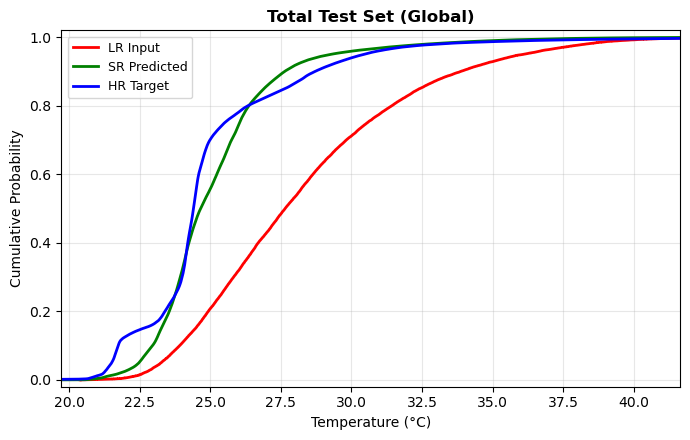

--------------------------------------------------------------------------------
Generating Individual CDFs for 3 Campaigns...


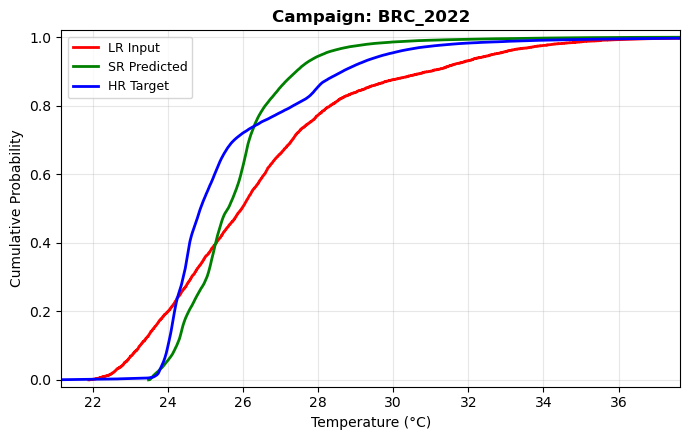

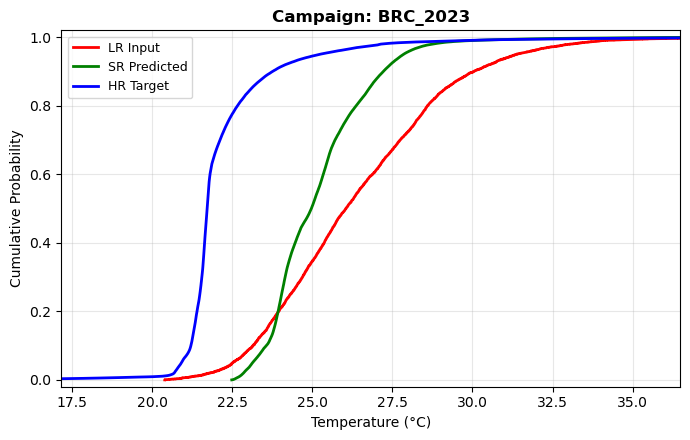

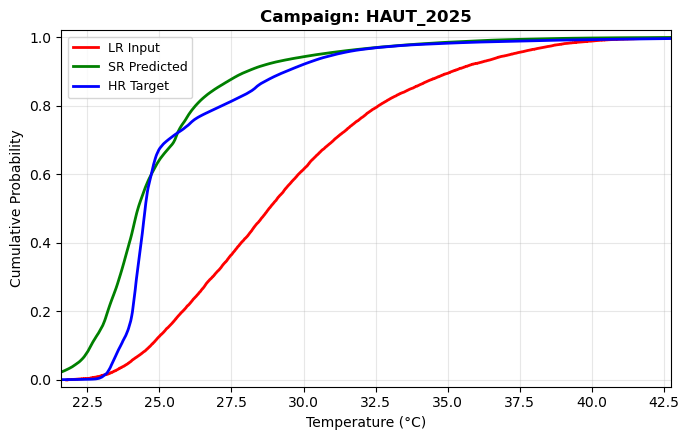

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Setup colors
palette = {"HR": "blue", "LR": "red", "SR": "green"}

# Helper function to plot a single, standalone CDF figure
def plot_standalone_cdf(lr_v, sr_v, hr_v, title_name):
    # Create an independent figure for this specific plot
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # Calculate bounds based on 0.5% and 99.5% percentiles
    xmin = min(np.percentile(hr_v, 0.5), np.percentile(lr_v, 0.5)) - 1.0
    xmax = max(np.percentile(hr_v, 99.5), np.percentile(lr_v, 99.5)) + 1.0
    
    for vec, key, lbl in [(lr_v, "LR", "LR Input"),
                          (sr_v, "SR", "SR Predicted"), 
                          (hr_v, "HR", "HR Target")]:
        sorted_data = np.sort(vec)
        y_values = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        ax.plot(sorted_data, y_values, color=palette[key], lw=2.0, label=lbl)
        
    ax.set_title(title_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Temperature (°C)", fontsize=10)
    ax.set_ylabel("Cumulative Probability", fontsize=10)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)
    
    plt.tight_layout()
    plt.show()  # Forces the cell to output this plot independently before moving on


# ─────────────────────────────────────────────────────────────
# 1. PLOT standalone TOTAL GLOBAL TEST SET
# ─────────────────────────────────────────────────────────────
print("Generating Global Total Test Set CDF...")

global_hr_v = hr[pure_water_mask]
global_sr_v = sr[pure_water_mask]

global_lr_v_list = []
for i in range(len(lr)):
    lr_up = np.repeat(np.repeat(lr[i], 4, axis=0), 4, axis=1)
    global_lr_v_list.append(lr_up[pure_water_mask[i]])
global_lr_v = np.concatenate(global_lr_v_list) if len(global_lr_v_list) > 0 else np.array([])

if len(global_hr_v) > 0 and len(global_lr_v) > 0:
    plot_standalone_cdf(global_lr_v, global_sr_v, global_hr_v, "Total Test Set (Global)")
else:
    print("[WARN] No global water pixels found to plot.")

print("-" * 80)


# ─────────────────────────────────────────────────────────────
# 2. PLOT standalone PER-CAMPAIGN CDFs
# ─────────────────────────────────────────────────────────────
unique_campaigns = np.unique(campaigns)
print(f"Generating Individual CDFs for {len(unique_campaigns)} Campaigns...")

for camp in unique_campaigns:
    camp_idx = (campaigns == camp)
    camp_water_mask = pure_water_mask[camp_idx]
    
    hr_v = hr[camp_idx][camp_water_mask]
    sr_v = sr[camp_idx][camp_water_mask]
    
    lr_v_list = []
    camp_lr = lr[camp_idx]
    for i in range(len(camp_lr)):
        lr_up = np.repeat(np.repeat(camp_lr[i], 4, axis=0), 4, axis=1)
        lr_v_list.append(lr_up[camp_water_mask[i]])
    lr_v = np.concatenate(lr_v_list) if len(lr_v_list) > 0 else np.array([])
    
    if len(hr_v) == 0 or len(lr_v) == 0:
        print(f"Skipping Campaign {camp}: Insufficient water pixels.")
        continue
        
    # Generate standalone figure context for this campaign run
    plot_standalone_cdf(lr_v, sr_v, hr_v, f"Campaign: {camp}")

### Discriminator output realness map

In [ ]:
import sys
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

# ==========================================
# 1. PATHS & INITIALIZATION
# ==========================================
BASE          = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR   = BASE / "data/processed/patches"
STATS_PATH    = PATCHES_DIR / "stats.json"
MODEL_PATH    = BASE / "checkpoints/gan_final/exp2_fixed_lr_schedule_epoch=56_val_water_mae=0.8773.ckpt"

sys.path.insert(0, str(BASE))

from scripts.models.realesrgan import RealESRGANModule
from scripts.utils.dataset import SRDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset normalization statistics
with open(STATS_PATH) as f:
    stats_data = json.load(f)

HR_MEAN = stats_data["hr"]["mean"]
HR_STD  = stats_data["hr"]["std"]

# ==========================================
# 2. LOAD MODEL & DATASETS
# ==========================================
print("Loading model checkpoint...")
model = RealESRGANModule.load_from_checkpoint(MODEL_PATH, strict=False).to(device).eval()

print("Initializing datasets...")
val_ds = SRDataset(
    split="val",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,                
    aux_dir=str(PATCHES_DIR / "val" / "AUX"),
    transform=None,
)

# Optional: Add train or test sets if you want to search across all splits
dataset_splits = {
    "val": val_ds,
}

# ==========================================
# 3. REALNESS MAP GENERATION FUNCTION
# ==========================================
def generate_and_save_realness_maps(model_obj, sample, save_prefix="realness_map"):
    """
    Passes a sample through the Generator and Discriminator, extracts pixel-wise
    realness scores, applies the valid HR mask, and saves side-by-side visualizations.
    """
    model_obj.eval()

    # Build input batch tensor on device
    batch = {
        "lr": sample["lr"].unsqueeze(0).to(device),
        "aux_lr": sample["aux_lr"].unsqueeze(0).to(device),
        "aux_mid": sample["aux_mid"].unsqueeze(0).to(device),
        "aux_hr": sample["aux_hr"].unsqueeze(0).to(device),
        "time_channels": sample["time_channels"].unsqueeze(0).to(device),
        "time_gap_hours": sample["time_gap_hours"].unsqueeze(0).to(device),
        "date_gap_days": sample["date_gap_days"].unsqueeze(0).to(device),
    }

    hr_gt = sample["hr"].unsqueeze(0).to(device)
    hr_mask = sample["hr_mask"].squeeze().numpy()
    valid = hr_mask > 0.5  # Mask for valid flight path / water pixels

    # Locate discriminator module in the Lightning Wrapper
    discriminator = getattr(model_obj, 'discriminator', getattr(model_obj, 'net_d', None))
    if discriminator is None:
        raise AttributeError("Could not locate discriminator module (`net_d` or `discriminator`) in model.")

    with torch.no_grad():
        # 1. Forward pass through Generator
        sr_tensor = model_obj(batch)  # Output shape: [1, 1, H, W]

        # 2. Prepare 3-channel input for Discriminator (Thermal 1-ch + AUX_HR 2-ch)
        if sr_tensor.shape[1] == 1 and batch["aux_hr"].shape[1] == 2:
            disc_input_sr = torch.cat([sr_tensor, batch["aux_hr"]], dim=1)
            disc_input_hr = torch.cat([hr_gt, batch["aux_hr"]], dim=1)
        else:
            disc_input_sr = sr_tensor.repeat(1, 3, 1, 1)
            disc_input_hr = hr_gt.repeat(1, 3, 1, 1)

        # 3. Forward pass through Discriminator
        raw_scores_sr = discriminator(disc_input_sr)
        raw_scores_hr = discriminator(disc_input_hr)

    # Convert output feature maps to NumPy 2D arrays
    scores_sr = raw_scores_sr.detach().cpu().squeeze().numpy()
    scores_hr = raw_scores_hr.detach().cpu().squeeze().numpy()

    # Joint min-max normalization across valid regions
    valid_sr = scores_sr[valid] if scores_sr.shape == valid.shape else scores_sr
    valid_hr = scores_hr[valid] if scores_hr.shape == valid.shape else scores_hr

    combined_min = min(valid_sr.min(), valid_hr.min())
    combined_max = max(valid_sr.max(), valid_hr.max())

    norm_sr = (scores_sr - combined_min) / (combined_max - combined_min + 1e-8)
    norm_hr = (scores_hr - combined_min) / (combined_max - combined_min + 1e-8)

    # Apply invalid mask (set non-flight/land pixels to NaN)
    if norm_sr.shape == valid.shape:
        norm_sr = np.where(valid, norm_sr, np.nan)
        norm_hr = np.where(valid, norm_hr, np.nan)

    # Render color-mapped figures
    cmap = cm.get_cmap('jet')
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(norm_sr, cmap=cmap, vmin=0, vmax=1)
    axes[0].set_title("SR Pixel-wise Realness Map $D(G(x))$")
    axes[0].axis("off")

    im1 = axes[1].imshow(norm_hr, cmap=cmap, vmin=0, vmax=1)
    axes[1].set_title("Ground Truth (HR) Realness Map $D(y)$")
    axes[1].axis("off")

    cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Discriminator Realness Score (0 = Low/Fake, 1 = High/Real)")

    save_fig_path = f"{save_prefix}_comparison.png"
    plt.savefig(save_fig_path, bbox_inches='tight', dpi=300)
    plt.close()

    print(f"[SUCCESS] Realness map figure saved to: {save_fig_path}")

# ==========================================
# 4. TARGET FILE LOOKUP & EXECUTION
# ==========================================
def process_target_file(target_fname):
    target_clean = target_fname.replace(".npy", "").replace(".tif", "")
    found_sample = None
    found_split = None

    print(f"\nSearching for patch: '{target_fname}'...")
    for split_name, ds in dataset_splits.items():
        if ds is None:
            continue
        for i in range(len(ds)):
            sample_fname = ds[i]["fname"]
            if target_clean in sample_fname:
                found_sample = ds[i]
                found_split = split_name
                print(f"Found in '{split_name}' dataset at index {i}.")
                break
        if found_sample is not None:
            break

    if found_sample is None:
        raise FileNotFoundError(f"Could not locate sample '{target_fname}' in provided dataset splits.")

    save_prefix = f"realness_{found_split}_{target_clean}"
    generate_and_save_realness_maps(model, found_sample, save_prefix=save_prefix)

if __name__ == "__main__":
    TARGET_FILE = "PDR_2013_b1_r1536_c512.npy"
    process_target_file(TARGET_FILE)

Using device: cuda
Loading model checkpoint...
[INFO] generator loaded 702 params
[INFO] discriminator loaded 28 params


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:193: Found keys that are in the model state dict but not in the checkpoint: ['net_g.net.conv_first.weight', 'net_g.net.conv_first.bias', 'net_g.net.body.0.rdb1.conv1.weight', 'net_g.net.body.0.rdb1.conv1.bias', 'net_g.net.body.0.rdb1.conv2.weight', 'net_g.net.body.0.rdb1.conv2.bias', 'net_g.net.body.0.rdb1.conv3.weight', 'net_g.net.body.0.rdb1.conv3.bias', 'net_g.net.body.0.rdb1.conv4.weight', 'net_g.net.body.0.rdb1.conv4.bias', 'net_g.net.body.0.rdb1.conv5.weight', 'net_g.net.body.0.rdb1.conv5.bias', 'net_g.net.body.0.rdb2.conv1.weight', 'net_g.net.body.0.rdb2.conv1.bias', 'net_g.net.body.0.rdb2.conv2.weight', 'net_g.net.body.0.rdb2.conv2.bias', 'net_g.net.body.0.rdb2.conv3.weight', 'net_g.net.body.0.rdb2.conv3.bias', 'net_g.net.body.0.rdb2.conv4.weight', 'net_g.net.body.0.rdb2.conv4.bias', 'net_g.net.body.0.rdb2.conv5.weight', 'net_g.net.body.0.rdb2.conv5.bias', 'net_g.net.body.0.rdb3.

Initializing datasets...

Searching for patch: 'PDR_2013_b1_r1536_c512.npy'...
Found in 'val' dataset at index 30.


/tmp/ipykernel_3503885/2908873822.py:120: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')


[SUCCESS] Realness map figure saved to: realness_val_PDR_2013_b1_r1536_c512_comparison.png
